# 1 · Análisis exploratorio de datos (EDA)

**Objetivo del capítulo.** Entender la estructura, la calidad y las relaciones de los datos de
*Lending Club* **antes** de preprocesar o modelar, y dejar por escrito las decisiones que de ahí
se derivan.

**Pregunta de investigación.** Dado un préstamo en el momento de otorgarlo, ¿cuál es la probabilidad
de que termine en incumplimiento (*Charged Off*)?

## Orden del análisis: partición previa a la exploración

Si se explora el conjunto completo antes de dividirlo, las decisiones que se toman al explorar (qué
variables usar, qué umbrales, qué transformaciones) quedan influidas por datos que, en la práctica,
todavía no se conocerían. Por eso este capítulo sigue este orden:

1. **Carga y estructura** del archivo completo (dimensiones, tipos, columnas): no usan la etiqueta.
2. **Se define la población y se hace la partición 80/20** (estratificada) y se guarda.
3. **Todo análisis que mire la variable objetivo, las distribuciones o las relaciones** (auditoría
   de fuga, faltantes, valores atípicos, correlaciones, pruebas) usa **solo el entrenamiento**. El 20 % de
   prueba se aparta y no se examina hasta la evaluación final.

```{note}
Se usa el archivo **completo** (2 260 701 filas × 151 columnas), sin muestreo. Las únicas excepciones
son unas pocas visualizaciones costosas (*pairplot*, violines, matriz de dispersión), donde se
dibuja una muestra aleatoria **solo para el gráfico**, y dos pruebas que se calculan sobre muestras
por costo o por validez de la prueba: Shapiro-Wilk (5 000 filas) y el V de Cramér entre pares de
variables categóricas (300 000 filas). El resto de estadísticas y pruebas usa todas las filas de
entrenamiento.
```

Orden: (1.1) carga y visión general · (1.2) la variable objetivo · (1.3) partición ·
(1.4) auditoría de fuga · (1.5) valores faltantes · (1.6) univariado · (1.7) bivariado ·
(1.8) multicolinealidad · (1.9) visualizaciones avanzadas · (1.10) sesgo temporal ·
(1.11) resumen ejecutivo.

In [1]:
import gc
import platform
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_utils as lc  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="The figure layout has changed to tight")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS, DATA_DIR = Path("../resultados"), Path("../data")
RESULTS.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
proc = psutil.Process()
print(f"Python {platform.python_version()} · pandas {pd.__version__} · numpy {np.__version__} "
      f"· RAM total {psutil.virtual_memory().total / 1e9:.1f} GB")

Python 3.10.21 · pandas 2.1.0 · numpy 1.25.2 · RAM total 16.9 GB


## 1.1 Carga inicial y visión general

Se carga el CSV **completo** con `pandas` (sin `nrows`, `sample` ni filtros de filas). En el
capítulo de PySpark se mide el mismo proceso con Spark para comparar tiempos de carga.

In [2]:
t0 = time.time()
df = pd.read_csv(lc.DATA_PATH, low_memory=False)
T_CARGA_PANDAS = time.time() - t0
print(f"Carga con pandas: {T_CARGA_PANDAS:.1f} s | memoria del proceso: {proc.memory_info().rss / 1e9:.2f} GB")
print(f"Dimensión del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
n_filas_archivo, n_cols_archivo = df.shape

Carga con pandas: 121.5 s | memoria del proceso: 3.26 GB
Dimensión del dataset: 2,260,701 filas × 151 columnas


In [3]:
cols_vista = ["id", "loan_amnt", "term", "int_rate", "grade", "emp_length", "home_ownership",
              "annual_inc", "purpose", "dti", "fico_range_high", "loan_status"]
print("Primeras filas (head):")
display(df[cols_vista].head())
print("Últimas filas (tail):")
display(df[cols_vista].tail())

Primeras filas (head):


,id,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,purpose,dti,fico_range_high,loan_status
0,68407277,"3,600.000",36 months,13.990,C,10+ years,MORTGAGE,"55,000.000",debt_consolidation,5.910,679.000,Fully Paid
1,68355089,"24,700.000",36 months,11.990,C,10+ years,MORTGAGE,"65,000.000",small_business,16.060,719.000,Fully Paid
2,68341763,"20,000.000",60 months,10.780,B,10+ years,MORTGAGE,"63,000.000",home_improvement,10.780,699.000,Fully Paid
3,66310712,"35,000.000",60 months,14.850,C,10+ years,MORTGAGE,"110,000.000",debt_consolidation,17.060,789.000,Current
4,68476807,"10,400.000",60 months,22.450,F,3 years,MORTGAGE,"104,433.000",major_purchase,25.370,699.000,Fully Paid


Últimas filas (tail):


,id,loan_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,purpose,dti,fico_range_high,loan_status
2260696,88985880,"40,000.000",60 months,10.490,B,9 years,MORTGAGE,"227,000.000",debt_consolidation,12.750,709.000,Current
2260697,88224441,"24,000.000",60 months,14.490,C,6 years,RENT,"110,000.000",debt_consolidation,18.300,664.000,Charged Off
2260698,88215728,"14,000.000",60 months,14.490,C,10+ years,MORTGAGE,"95,000.000",debt_consolidation,23.360,664.000,Current
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observación.** Las dos últimas filas del archivo **no son préstamos**: en `id` traen el texto
"Total amount funded in policy code 1/2: …", es decir, totales que Lending Club agregó al final.
Por eso el archivo trae 33 filas con `loan_status` vacío (las 2 de totales y otras 31 sin
información). Estas filas se descartan al definir la población; el problema solo se advierte al inspeccionar el final del archivo.

In [4]:
print("info() resumido:")
df.info(verbose=False, memory_usage="deep")
tipos = df.dtypes.value_counts().rename("columnas").to_frame()
tipos.index = tipos.index.astype(str)
display(tipos)

info() resumido:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 6.3 GB


,columnas
float64,113
object,38


In [5]:
desc = df.describe(include="number").T
desc.to_csv(RESULTS / "describe_completo.csv")
print(f"describe() de las {len(desc)} columnas numéricas guardado en resultados/describe_completo.csv")
display(desc.loc[["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_high",
                  "open_acc", "revol_bal", "revol_util", "total_acc"]])

describe() de las 113 columnas numéricas guardado en resultados/describe_completo.csv


,count,mean,std,min,25%,50%,75%,max
loan_amnt,"2,260,668.000","15,046.931","9,190.245",500.000,"8,000.000","12,900.000","20,000.000","40,000.000"
int_rate,"2,260,668.000",13.093,4.832,5.310,9.490,12.620,15.990,30.990
installment,"2,260,668.000",445.807,267.174,4.930,251.650,377.990,593.320,"1,719.830"
annual_inc,"2,260,664.000","77,992.429","112,696.200",0.000,"46,000.000","65,000.000","93,000.000","110,000,000.000"
dti,"2,258,957.000",18.824,14.183,-1.000,11.890,17.840,24.490,999.000
fico_range_high,"2,260,668.000",702.588,33.011,614.000,679.000,694.000,719.000,850.000
open_acc,"2,260,639.000",11.612,5.641,0.000,8.000,11.000,14.000,101.000
revol_bal,"2,260,668.000","16,658.458","22,948.305",0.000,"5,950.000","11,324.000","20,246.000","2,904,836.000"
revol_util,"2,258,866.000",50.338,24.713,0.000,31.500,50.300,69.400,892.300
total_acc,"2,260,639.000",24.163,11.988,1.000,15.000,22.000,31.000,176.000


Los rangos ya insinúan problemas de calidad que se estudiarán en el entrenamiento:
`annual_inc` llega a más de 100 millones, `dti` a 999 y `revol_util` a cerca de 900 %.

## 1.2 Variable objetivo y población de estudio

La variable `loan_status` toma diez valores (tabla siguiente). La definición más directa de la variable
objetivo sería `default = 1` si `loan_status` es `Charged Off` y `0` en cualquier otro caso.

,préstamos,%
loan_status,,
Fully Paid,1076751,47.629
Current,878317,38.852
Charged Off,268559,11.879
Late (31-120 days),21467,0.950
In Grace Period,8436,0.373
Late (16-30 days),4349,0.192
Does not meet the credit policy. Status:Fully Paid,1988,0.088
Does not meet the credit policy. Status:Charged Off,761,0.034
Default,40,0.002


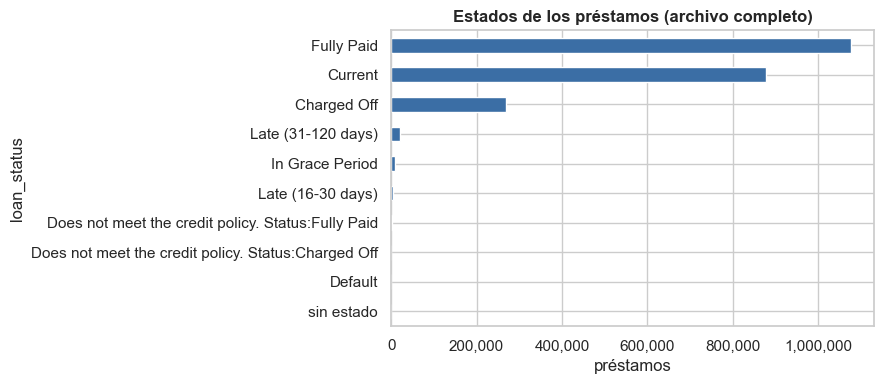

In [6]:
estados = df["loan_status"].value_counts(dropna=False).rename("préstamos").to_frame()
estados["%"] = 100 * estados["préstamos"] / len(df)
estados = estados.rename(index={np.nan: "sin estado"})
display(estados)

fig, ax = plt.subplots(figsize=(9, 4))
estados["préstamos"].iloc[::-1].plot.barh(ax=ax, color="#3b6ea5")
ax.set(title="Estados de los préstamos (archivo completo)", xlabel="préstamos")
ax.xaxis.set_major_formatter(lambda v, pos: f"{v:,.0f}")
plt.tight_layout()
plt.show()

Esa definición marcaría como `0 = Fully Paid` a **todos** los préstamos que no son
*Charged Off*, incluidos 878 317 préstamos *Current* (siguen pagándose; su desenlace aún no se
conoce), además de 34 252 atrasados o en periodo de gracia y 2 822 filas en otros estados. Etiquetar
como pagados a los vigentes sesgaría la etiqueta (mezclaría "pagó" con "todavía no se sabe") y
reduciría la tasa de incumplimiento aparente del 20.0 % al 11.9 %.

La variable objetivo se define entonces solo para préstamos con desenlace conocido: `Fully Paid` (0) y
`Charged Off` (1). La restricción se aplica por igual a todas las filas y no es un muestreo: se lee y
procesa el archivo completo.

In [7]:
literal = (df["loan_status"] == "Charged Off").astype(int)
resuelto = df["loan_status"].isin(lc.RESOLVED)
comp = pd.DataFrame({
    "filas": [len(df), int(resuelto.sum())],
    "default = 1": [int(literal.sum()), int((df.loc[resuelto, "loan_status"] == "Charged Off").sum())],
}, index=["Fórmula literal (todo el archivo)", "Solo desenlace conocido (Fully Paid / Charged Off)"])
comp["tasa de incumplimiento"] = comp["default = 1"] / comp["filas"]
display(comp.style.format({"filas": "{:,.0f}", "default = 1": "{:,.0f}", "tasa de incumplimiento": "{:.2%}"}))

# Conteos por año de otorgamiento (estructura del archivo; se usan en la sección 1.10)
anio_todos = pd.to_numeric(df["issue_d"].str[-4:], errors="coerce").dropna().astype(int).value_counts().sort_index()
anio_resueltos = pd.to_numeric(df.loc[resuelto, "issue_d"].str[-4:], errors="coerce").dropna().astype(int).value_counts().sort_index()

,filas,default = 1,tasa de incumplimiento
Fórmula literal (todo el archivo),"2,260,701","268,559",11.88%
Solo desenlace conocido (Fully Paid / Charged Off),"1,345,310","268,559",19.96%


La tasa real de incumplimiento entre préstamos con desenlace conocido es ≈ 20 %; la definición
directa la subestima (≈ 12 %) porque cuenta los préstamos aún vigentes como si fueran buenos.

## 1.3 Partición entrenamiento / prueba (antes de explorar)

Se construye la tabla de modelado (solo desenlace conocido) y se hace **ahora** la partición 80/20
**estratificada** (misma proporción de incumplimientos en ambos lados) con semilla fija. La asignación
se guarda **una sola vez** en `data/split_ids.parquet` con las columnas `id` y `split` (`train` / `test`),
más `fold` (pliegue 0, 1 o 2 de las filas de entrenamiento, también estratificado) y `rank` (orden aleatorio
fijo, para los experimentos de escala). Todos los capítulos (scikit-learn y PySpark) leen
**exactamente este archivo**: así se comparan modelos sobre los mismos préstamos (requisito de la prueba de
DeLong) y ambos entornos validan con **los mismos 3 pliegues**.

**A partir de aquí, el conjunto de prueba no se toca**: se descarta de la memoria de este cuaderno.

In [8]:
m_all = lc.build_model_frame(df[lc.RAW_COLUMNS])
split = lc.make_split(m_all)
split.to_parquet(DATA_DIR / "split_ids.parquet", index=False)
es_test = (split["split"] == "test").to_numpy()
print(f"Población modelada: {len(m_all):,} préstamos · entrenamiento {int((~es_test).sum()):,} "
      f"({100 * (~es_test).mean():.0f} %) · prueba {int(es_test.sum()):,} ({100 * es_test.mean():.0f} %)")
print(f"Estratificación: incumplimiento en train {m_all.loc[~es_test, 'default'].mean():.4f} · "
      f"en test {m_all.loc[es_test, 'default'].mean():.4f} (deben ser casi idénticos)")
print("Pliegues de validación cruzada (solo entrenamiento):",
      split.loc[~es_test, "fold"].value_counts().sort_index().to_dict(),
      "· columnas guardadas:", ["id", "split", "fold", "rank"])

# Se conservan SOLO las filas de entrenamiento (tabla de modelado y las 151 columnas originales).
m = m_all.loc[~es_test].reset_index(drop=True)
pos_resueltos = np.flatnonzero(resuelto.to_numpy())              # posiciones en df de los préstamos con desenlace
df_tr = df.iloc[pos_resueltos[~es_test]]                          # sus filas de entrenamiento, con todas las columnas
n_train, n_test = int((~es_test).sum()), int(es_test.sum())
del df, m_all, split, literal
gc.collect()
print(f"Memoria del proceso tras separar el test: {proc.memory_info().rss / 1e9:.2f} GB · "
      f"de aquí en adelante solo existe el entrenamiento ({len(m):,} filas)")

Población modelada: 1,345,310 préstamos · entrenamiento 1,076,248 (80 %) · prueba 269,062 (20 %)
Estratificación: incumplimiento en train 0.1996 · en test 0.1996 (deben ser casi idénticos)
Pliegues de validación cruzada (solo entrenamiento): {0: 358750, 1: 358749, 2: 358749} · columnas guardadas: ['id', 'split', 'fold', 'rank']


Memoria del proceso tras separar el test: 2.29 GB · de aquí en adelante solo existe el entrenamiento (1,076,248 filas)


## 1.4 Auditoría de fuga de datos (*data leakage*)

Lending Club publica columnas que se generan **después** de otorgar el préstamo (pagos recibidos,
recuperaciones, último pago…). Un modelo que las use incurriría en fuga de datos: aprendería del
desenlace, y ese modelo jamás podría usarse para decidir a quién prestar. Se mide qué tan
informativas son (AUC de cada columna por separado contra `default`; 0.5 = nada, 1.0 = perfecta)
para justificar que **no** se usen.

```{note}
`int_rate` sí está disponible al originar el préstamo, así que no es fuga temporal. Pero la tasa la
fija Lending Club con su propio modelo de riesgo, por lo que resume parcialmente esa evaluación
interna. Los resultados que dependen de `int_rate` deben leerse como una predicción condicionada a
la tasa ya asignada, no como una evaluación de riesgo desde cero.
```

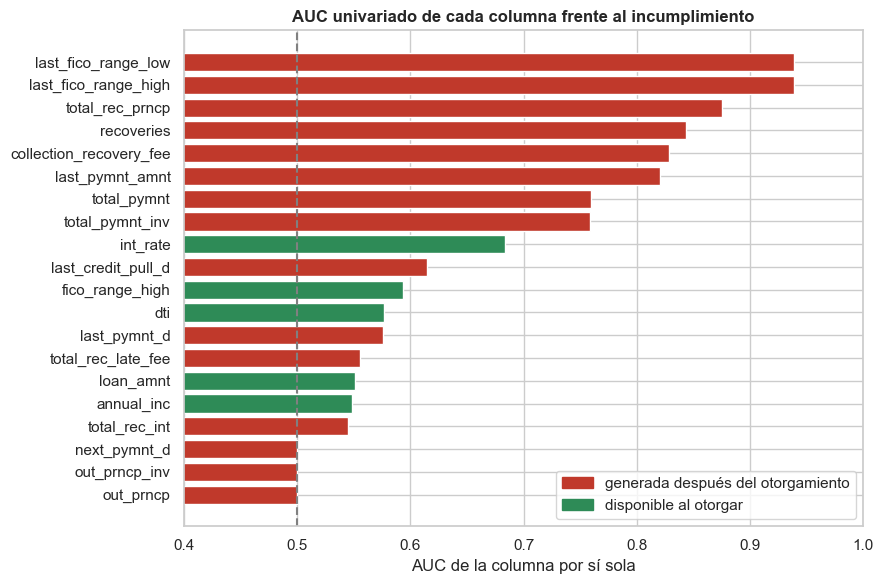

Mayor AUC individual entre columnas posteriores al préstamo: last_fico_range_low = 0.939
Mayor AUC individual entre las variables disponibles al originar: int_rate = 0.684
Columnas posteriores con AUC > 0.7: 8 de 15


In [9]:
y_tr = m["default"].to_numpy()
aud = {}
for c in lc.POST_ORIGINATION:
    x = lc._year_month(df_tr[c]) if c.endswith("_d") else pd.to_numeric(df_tr[c], errors="coerce")
    a = roc_auc_score(y_tr, x.fillna(-1).to_numpy())
    aud[c] = max(a, 1 - a)
DISPONIBLES = ["int_rate", "fico_range_high", "dti", "annual_inc", "loan_amnt"]      # disponibles al originar
for c in DISPONIBLES:
    a = roc_auc_score(y_tr, pd.to_numeric(df_tr[c], errors="coerce").fillna(-1).to_numpy())
    aud[c] = max(a, 1 - a)
aud = pd.Series(aud).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(aud.index, aud.values, color=["#2e8b57" if k in DISPONIBLES else "#c0392b" for k in aud.index])
ax.axvline(0.5, color="gray", ls="--")
ax.set(xlim=(0.4, 1.0), xlabel="AUC de la columna por sí sola",
       title="AUC univariado de cada columna frente al incumplimiento")
from matplotlib.patches import Patch  # noqa: E402
ax.legend(handles=[Patch(color="#c0392b", label="generada después del otorgamiento"),
                   Patch(color="#2e8b57", label="disponible al otorgar")], loc="lower right")
plt.tight_layout()
plt.show()
post = aud[[i for i in aud.index if i not in DISPONIBLES]]
AUD_MAX = float(post.max())
disp = aud[DISPONIBLES]
print(f"Mayor AUC individual entre columnas posteriores al préstamo: {post.idxmax()} = {AUD_MAX:.3f}")
print(f"Mayor AUC individual entre las variables disponibles al originar: {disp.idxmax()} = {disp.max():.3f}")
print(f"Columnas posteriores con AUC > 0.7: {int((post > 0.7).sum())} de {len(post)}")

Varias columnas generadas después del préstamo separan por sí solas a los
incumplidores mucho mejor que cualquier variable disponible al originar (comparar las barras rojas
con las verdes). Un modelo que las use tendría un AUC casi perfecto y un valor práctico **nulo**:
no se pueden conocer al decidir a quién prestar. Por eso el modelo usa solo variables conocidas en
el momento de otorgar el préstamo (lista en `src/lc_utils.py`).

## 1.5 Valores faltantes

### 1.5.1 Panorama de las 151 columnas (filas de entrenamiento)

Columnas sin ningún nulo: 47 · con >70 % nulos: 42 · con >30 % nulos: 58


,nulos,%
next_pymnt_d,1076248,100.000
member_id,1076248,100.000
orig_projected_additional_accrued_interest,1073233,99.720
hardship_start_date,1071605,99.569
hardship_length,1071605,99.569
hardship_type,1071605,99.569
hardship_reason,1071605,99.569
hardship_status,1071605,99.569
deferral_term,1071605,99.569
hardship_amount,1071605,99.569


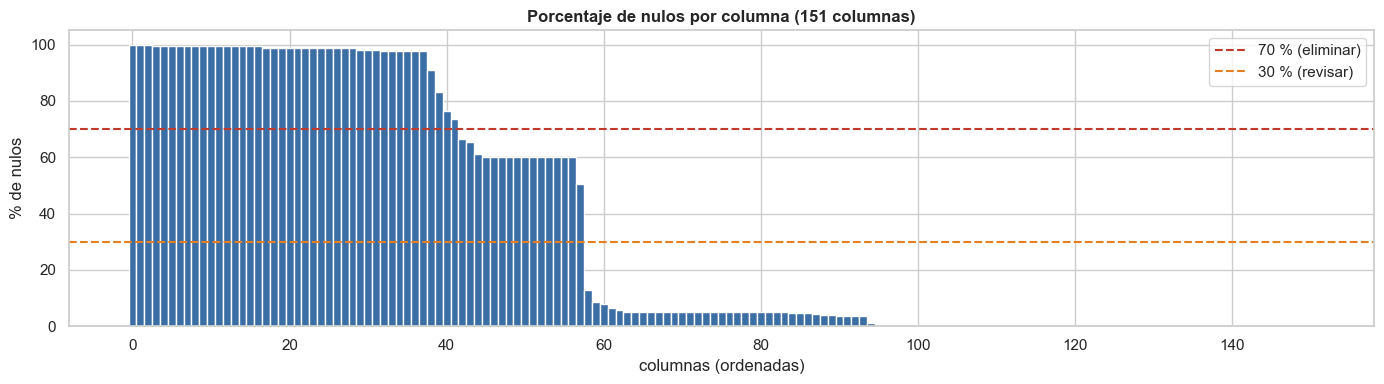

In [10]:
nulos = pd.DataFrame({"nulos": df_tr.isna().sum(), "%": 100 * df_tr.isna().mean()}).sort_values("%", ascending=False)
nulos.to_csv(RESULTS / "nulos_por_columna.csv")
N_MAS70, N_MAS30 = int((nulos["%"] > 70).sum()), int((nulos["%"] > 30).sum())
print(f"Columnas sin ningún nulo: {(nulos['nulos'] == 0).sum()} · con >70 % nulos: {N_MAS70} · con >30 % nulos: {N_MAS30}")
display(nulos.head(20))

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(nulos)), nulos["%"].values, color="#3b6ea5", width=1.0)
ax.axhline(70, color="#c0392b", ls="--", label="70 % (eliminar)")
ax.axhline(30, color="#e67e22", ls="--", label="30 % (revisar)")
ax.set(xlabel="columnas (ordenadas)", ylabel="% de nulos", title="Porcentaje de nulos por columna (151 columnas)")
ax.legend()
plt.tight_layout()
plt.show()

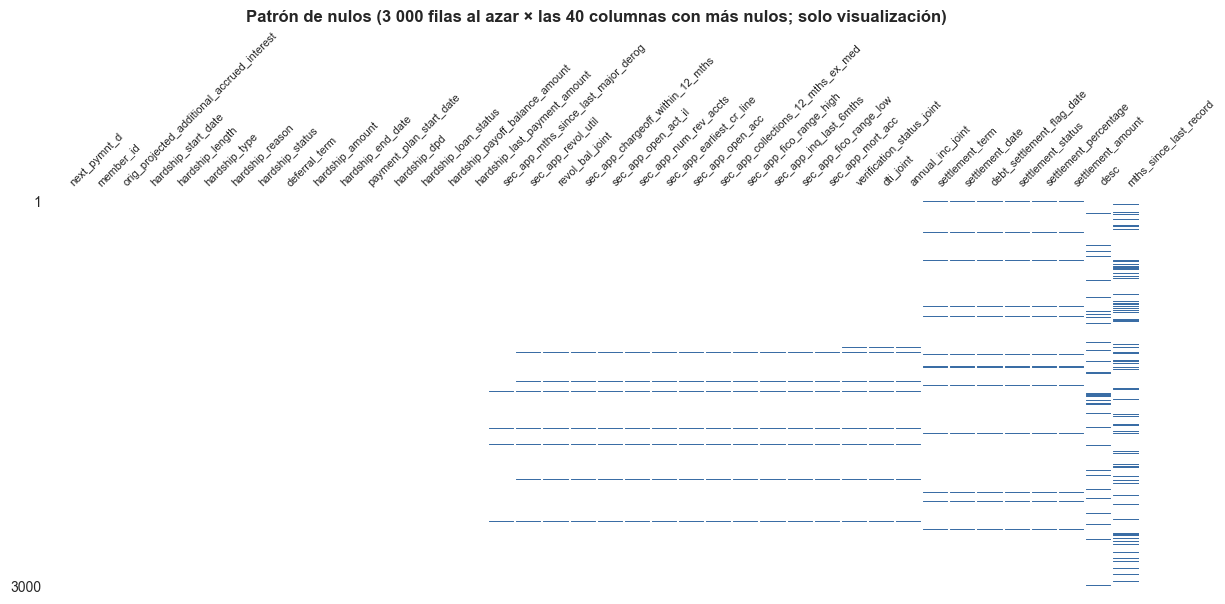

,columnas con >70 % de nulos
joint / co-solicitante,16
hardship,11
otras,9
settlement,6


In [11]:
top40 = nulos.head(40).index.tolist()
muestra = df_tr[top40].sample(3000, random_state=lc.SEED)     # solo para dibujar el patrón
msno.matrix(muestra, figsize=(14, 5), sparkline=False, fontsize=8, color=(0.23, 0.43, 0.65))
plt.title("Patrón de nulos (3 000 filas al azar × las 40 columnas con más nulos; solo visualización)")
plt.show()
prefijos = pd.Series([("hardship" if "hardship" in c else "settlement" if "settlement" in c else
                       "joint / co-solicitante" if ("joint" in c or c.startswith("sec_app")) else "otras")
                      for c in nulos[nulos["%"] > 70].index]).value_counts().rename("columnas con >70 % de nulos")
display(prefijos.to_frame())

Los nulos **no están repartidos al azar**: se concentran en bloques de columnas que se
vacían juntas (la tabla anterior agrupa las de más de 70 %: *hardship*, *settlement*, préstamos
conjuntos / co-solicitantes…). Es un patrón *sistemático* (depende del tipo de préstamo o de qué
empezó a registrar Lending Club y cuándo), no aleatorio.

### 1.5.2 Plan de tratamiento (regla por columna)

| Porcentaje de nulos | Tratamiento |
|---|---|
| > 70 % | Eliminar la columna (casi todas son posteriores al préstamo o de subpoblaciones) |
| 30 % – 70 % | Se excluyen del modelo, salvo justificación explícita (tabla siguiente) |
| < 30 % (variables del modelo) | Numéricas: valor centinela −1 (los árboles lo aíslan como "sin dato"); categóricas: categoría `Desconocido` |

El análisis de las variables que **sí** entran al modelo se presenta en la sección 1.5.3. La tabla
siguiente documenta cada columna de la franja 30–70 %, agrupada por el motivo real de su
nulidad en vez de una única regla genérica.

In [12]:
banda = nulos[(nulos["%"] > 30) & (nulos["%"] <= 70)].copy()
anio_col = pd.to_numeric(df_tr["issue_d"].str[-4:], errors="coerce")
early, late = anio_col <= 2012, anio_col >= 2016
banda["% nulos (préstamos ≤ 2012)"] = [100 * df_tr.loc[early, c].isna().mean() for c in banda.index]
banda["% nulos (préstamos ≥ 2016)"] = [100 * df_tr.loc[late, c].isna().mean() for c in banda.index]
banda["justificación"] = "nulidad estructural: Lending Club empezó a registrar esta variable en años recientes"
banda.loc["mths_since_last_delinq", "justificación"] = (
    "disponible al otorgar el préstamo; el nulo indica ausencia de morosidad registrada, no falta al azar")
banda.loc["mths_since_recent_revol_delinq", "justificación"] = (
    "disponible al otorgar el préstamo; el nulo indica ausencia de morosidad revolvente registrada, no falta al azar")
banda["decisión"] = "excluida (posible mejora: indicador de nulo)"
display(banda[["%", "% nulos (préstamos ≤ 2012)", "% nulos (préstamos ≥ 2016)", "decisión", "justificación"]]
        .rename(columns={"%": "% nulos (train)"}).style.format(
            {"% nulos (train)": "{:.1f}", "% nulos (préstamos ≤ 2012)": "{:.1f}", "% nulos (préstamos ≥ 2016)": "{:.1f}"}))

,% nulos (train),% nulos (préstamos ≤ 2012),% nulos (préstamos ≥ 2016),decisión,justificación
mths_since_recent_revol_delinq,66.5,85.1,65.5,excluida (posible mejora: indicador de nulo),"disponible al otorgar el préstamo; el nulo indica ausencia de morosidad revolvente registrada, no falta al azar"
il_util,65.4,100.0,13.5,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
mths_since_rcnt_il,61.1,100.0,2.6,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
all_util,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
total_cu_tl,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
inq_last_12m,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
open_acc_6m,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
max_bal_bc,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
open_rv_12m,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes
total_bal_il,60.0,100.0,0.0,excluida (posible mejora: indicador de nulo),nulidad estructural: Lending Club empezó a registrar esta variable en años recientes


In [13]:
# Se conservan solo columnas auxiliares (alineadas con `m`) para justificar descartes por redundancia.
extra = df_tr[["fico_range_low", "funded_amnt", "grade", "sub_grade"]].reset_index(drop=True)
assert len(extra) == len(m)
del df_tr
gc.collect()
print(f"Memoria del proceso ahora: {proc.memory_info().rss / 1e9:.2f} GB · tabla de modelado (train): {m.shape[0]:,} × {m.shape[1]}")

Memoria del proceso ahora: 1.69 GB · tabla de modelado (train): 1,076,248 × 24


### 1.5.3 Faltantes en las variables del modelo

,nulos,%
emp_length,62826,5.838
mort_acc,37953,3.526
revol_util,695,0.065
dti,296,0.028
inq_last_6mths,1,0.000


Con menos de 10 filas con nulo, la tasa de default y el χ² no son fiables y se dejan en blanco (inq_last_6mths).


,n con nulo,tasa default si falta,tasa default si no falta,diferencia,chi² p-valor
variable,,,,,
emp_length,62826,0.269,0.195,0.074,0.000
mort_acc,37953,0.145,0.202,-0.056,0.000
revol_util,695,0.209,0.200,0.009,0.552
dti,296,0.186,0.200,-0.014,0.552
inq_last_6mths,1,NaN,0.200,NaN,NaN


,emp_length,mort_acc,revol_util,dti,inq_last_6mths
año,,,,,
2007,0.0 %,100.0 %,0.0 %,0.0 %,0.0 %
2009,0.0 %,100.0 %,0.3 %,0.0 %,0.0 %
2011,3.5 %,100.0 %,0.1 %,0.0 %,0.0 %
2012,3.6 %,14.1 %,0.1 %,0.0 %,0.0 %
2013,4.4 %,0.0 %,0.1 %,0.0 %,0.0 %
2015,5.9 %,0.0 %,0.0 %,0.0 %,0.0 %
2018,8.8 %,0.0 %,0.1 %,0.3 %,0.0 %


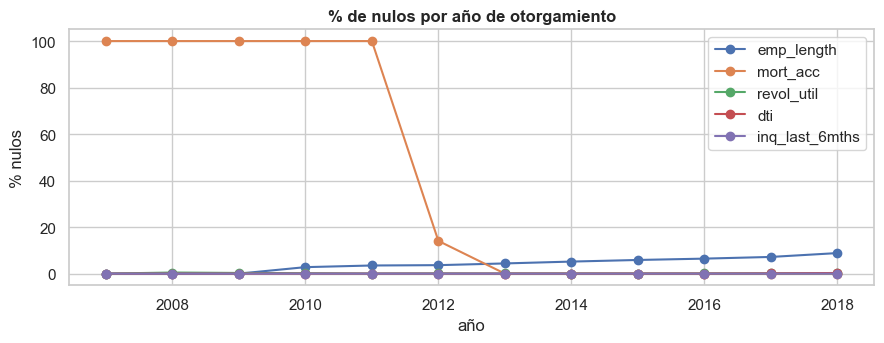

In [14]:
nm = m[lc.FEATURES].isna().sum().rename("nulos").to_frame()
nm["%"] = 100 * nm["nulos"] / len(m)
nm = nm[nm["nulos"] > 0].sort_values("%", ascending=False)
display(nm)

# ¿Se relacionan los nulos con el objetivo? (si sí, no son "completamente al azar", MCAR)
filas = []
for c in nm.index:
    falta = m[c].isna()
    n_falta = int(falta.sum())
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(falta, m["default"]), correction=False)
    filas.append({"variable": c, "n con nulo": n_falta,
                  "tasa default si falta": m.loc[falta, "default"].mean() if n_falta >= 10 else np.nan,
                  "tasa default si no falta": m.loc[~falta, "default"].mean(),
                  "diferencia": (m.loc[falta, "default"].mean() - m.loc[~falta, "default"].mean()) if n_falta >= 10 else np.nan,
                  "chi² p-valor": p if n_falta >= 10 else np.nan})
mcar = pd.DataFrame(filas).set_index("variable")
print("Con menos de 10 filas con nulo, la tasa de default y el χ² no son fiables y se dejan en blanco "
      f"({', '.join(mcar.index[mcar['n con nulo'] < 10])}).")
display(mcar)

nulos_anio = pd.DataFrame({c: m.groupby("issue_year")[c].apply(lambda s: 100 * s.isna().mean()) for c in nm.index})
display(nulos_anio.loc[[a for a in (2007, 2009, 2011, 2012, 2013, 2015, 2018) if a in nulos_anio.index]]
        .rename_axis("año").style.format("{:.1f} %"))
fig, ax = plt.subplots(figsize=(9, 3.6))
for c in nm.index:
    nulos_anio[c].plot(ax=ax, label=c, marker="o")
ax.set(title="% de nulos por año de otorgamiento", ylabel="% nulos", xlabel="año")
ax.legend()
plt.tight_layout()
plt.show()

Las tablas anteriores responden a dos preguntas:

* **¿Son nulos "al azar" (MCAR)?** Donde el χ² es significativo **y** la diferencia de tasas es
  material (`emp_length`, `mort_acc`), faltar **está relacionado con el desenlace**: no son MCAR.
  Imputar con la media borraría esa señal. Es un motivo para usar el centinela −1 en lugar de un
  estadístico y dejar que el árbol decida si "sin dato" es informativo.
* **¿Son estructurales?** En las variables donde el porcentaje de nulos depende fuertemente del año
  (tabla y gráfico por año), el faltante nace de **cuándo** se registró la variable, no de un error
  aleatorio.

Para las variables con muy pocos nulos (`revol_util`, `dti`, `inq_last_6mths`) el χ² no muestra
relación con el objetivo: el tratamiento es indiferente.

## 1.6 Análisis univariado

### 1.6.1 Variables numéricas

In [15]:
def resumen_numerico(s: pd.Series) -> dict:
    q1, q2, q3 = s.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = s.notna().sum()
    fuera = int(((s < lo) | (s > hi)).sum())
    return {"n": n, "faltantes %": 100 * s.isna().mean(), "media": s.mean(), "mediana": q2,
            "desv. est.": s.std(), "mín": s.min(), "P25": q1, "P75": q3, "máx": s.max(), "IQR": iqr,
            "límite inf.": lo, "límite sup.": hi, "outliers": fuera, "outliers %": 100 * fuera / n,
            "asimetría": s.skew(), "curtosis": s.kurt()}


tabla_num = pd.DataFrame({c: resumen_numerico(m[c]) for c in lc.NUMERIC}).T
tabla_num.to_csv(RESULTS / "eda_numericas.csv")
display(tabla_num[["n", "faltantes %", "media", "mediana", "desv. est.", "mín", "P25", "P75", "máx", "IQR"]])
display(tabla_num[["límite inf.", "límite sup.", "outliers", "outliers %", "asimetría", "curtosis"]])

,n,faltantes %,media,mediana,desv. est.,mín,P25,P75,máx,IQR
loan_amnt,"1,076,248.000",0.000,"14,420.946","12,000.000","8,719.169",500.000,"8,000.000","20,000.000","40,000.000","12,000.000"
int_rate,"1,076,248.000",0.000,13.242,12.740,4.771,5.310,9.750,15.990,30.990,6.240
installment,"1,076,248.000",0.000,438.117,375.430,261.582,4.930,248.460,580.730,"1,719.830",332.270
annual_inc,"1,076,248.000",0.000,"76,241.938","65,000.000","69,566.288",0.000,"45,802.770","90,000.000","9,550,000.000","44,197.230"
dti,"1,075,952.000",0.028,18.286,17.620,11.333,-1.000,11.790,24.060,999.000,12.270
fico_range_high,"1,076,248.000",0.000,700.193,694.000,31.872,629.000,674.000,714.000,850.000,40.000
emp_length,"1,013,422.000",5.838,5.965,6.000,3.691,0.000,2.000,10.000,10.000,8.000
open_acc,"1,076,248.000",0.000,11.593,11.000,5.479,0.000,8.000,14.000,90.000,6.000
revol_bal,"1,076,248.000",0.000,"16,246.323","11,135.000","22,252.252",0.000,"5,944.000","19,760.000","2,904,836.000","13,816.000"
revol_util,"1,075,553.000",0.065,51.821,52.200,24.527,0.000,33.500,70.800,892.300,37.300


,límite inf.,límite sup.,outliers,outliers %,asimetría,curtosis
loan_amnt,"-10,000.000","38,000.000","5,710.000",0.531,0.782,-0.085
int_rate,0.390,25.350,"20,025.000",1.861,0.714,0.508
installment,-249.945,"1,079.135","33,622.000",3.124,1.006,0.747
annual_inc,"-20,493.075","156,295.845","52,607.000",4.888,45.071,"4,591.357"
dti,-6.615,42.465,"4,318.000",0.401,28.428,"2,198.375"
fico_range_high,614.000,774.000,"37,258.000",3.462,1.286,1.660
emp_length,-10.000,22.000,0.000,0.000,-0.217,-1.499
open_acc,-1.000,23.000,"36,939.000",3.432,1.305,3.419
revol_bal,"-14,780.000","40,484.000","63,769.000",5.925,13.239,670.719
revol_util,-22.450,126.750,60.000,0.006,-0.028,0.504


**Valores imposibles o sospechosos** (más allá de los valores atípicos en sentido estadístico):

In [16]:
sospechosos = pd.Series({
    "dti = -1 (dato inválido)": int((m["dti"] < 0).sum()),
    "dti > 100 (más de 100 % de la deuda sobre ingreso)": int((m["dti"] > 100).sum()),
    "revol_util > 100 (uso de crédito > 100 %)": int((m["revol_util"] > 100).sum()),
    "annual_inc = 0": int((m["annual_inc"] == 0).sum()),
    "annual_inc > 1 000 000": int((m["annual_inc"] > 1_000_000).sum()),
}, name="filas")
sospechosos_pct = (100 * sospechosos / len(m)).rename("% de las filas")
display(pd.concat([sospechosos, sospechosos_pct], axis=1))

,filas,% de las filas
dti = -1 (dato inválido),1,0.000
dti > 100 (más de 100 % de la deuda sobre ingreso),428,0.040
revol_util > 100 (uso de crédito > 100 %),3781,0.351
annual_inc = 0,283,0.026
annual_inc > 1 000 000,242,0.022


Solo `dti = -1` se trata como faltante: coincide con el centinela −1 que usa el imputador
(sección 2.3), así que ese caso queda cubierto sin código adicional. Los demás valores de la tabla
(`dti` o `revol_util` por encima de 100, ingresos en cero o superiores al millón, historial de
crédito negativo) **no se recodifican**: son pocos, son valores extremos pero no imposibles para
estas variables, y los modelos de árbol no los tratan de forma especial.

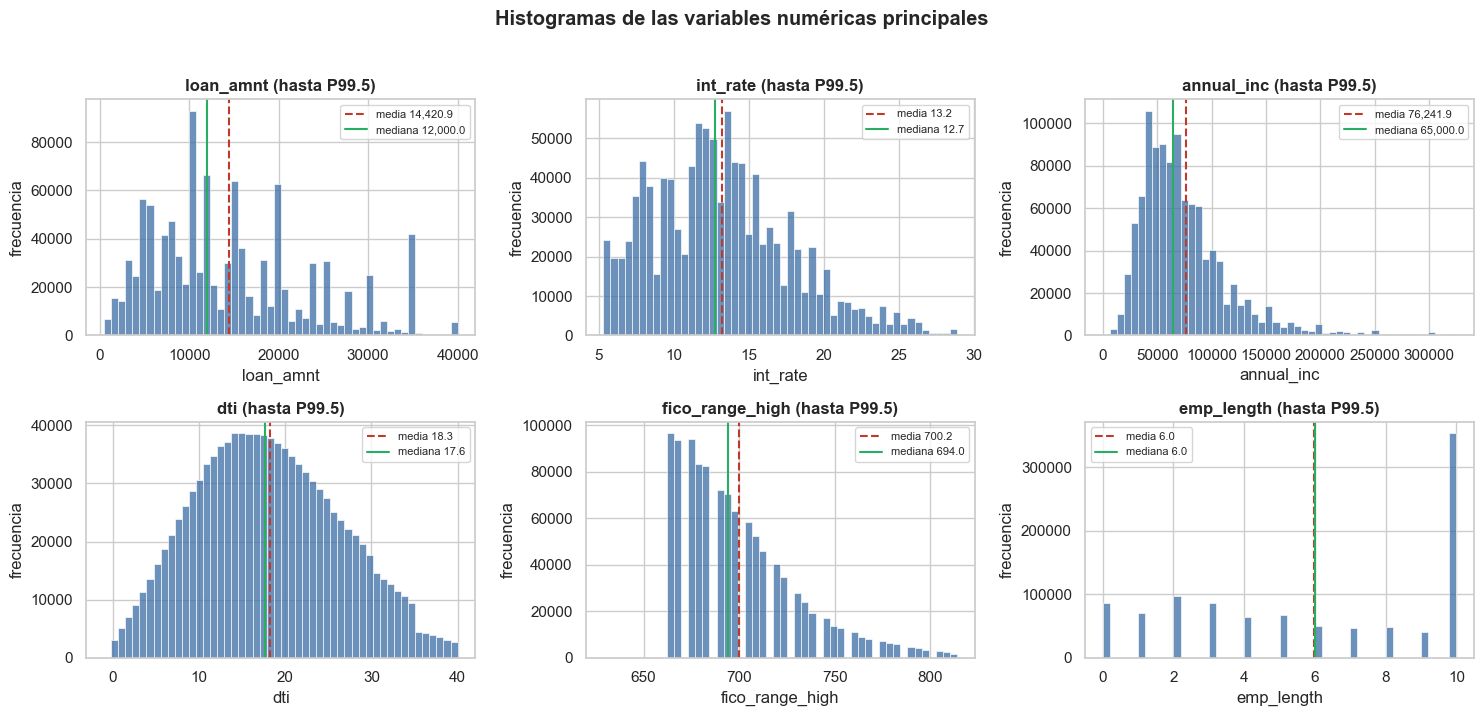

In [17]:
graficas = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_high", "emp_length"]
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(ax.ravel(), graficas):
    s = m[c].dropna()
    tope = s.quantile(0.995)         # solo para dibujar: recorta la cola extrema del gráfico
    sns.histplot(s[s <= tope], bins=50, ax=a, color="#3b6ea5")
    a.axvline(s.mean(), color="#c0392b", ls="--", label=f"media {s.mean():,.1f}")
    a.axvline(s.median(), color="#27ae60", ls="-", label=f"mediana {s.median():,.1f}")
    a.set(title=f"{c} (hasta P99.5)", ylabel="frecuencia")
    a.legend(fontsize=8)
plt.suptitle("Histogramas de las variables numéricas principales", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

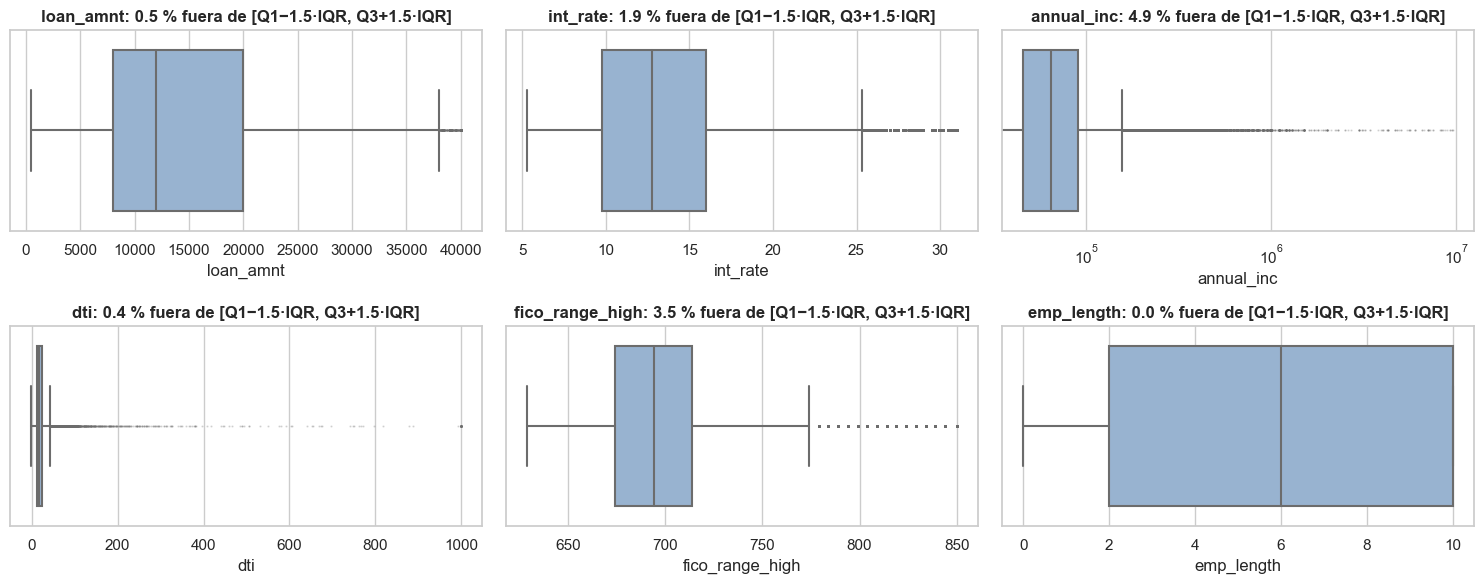

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
for a, c in zip(ax.ravel(), graficas):
    sns.boxplot(x=m[c], ax=a, color="#8fb3d9", fliersize=0.6, flierprops={"alpha": 0.25, "markersize": 0.6})
    a.set(title=f"{c}: {tabla_num.loc[c, 'outliers %']:.1f} % fuera de [Q1−1.5·IQR, Q3+1.5·IQR]")
    if c == "annual_inc":
        a.set_xscale("log")
plt.tight_layout()
plt.show()

El método del IQR no distingue por sí solo un valor extremo **posible** de uno **inválido**; esa
distinción se hace variable por variable, a partir de lo que cada una puede tomar en la realidad:

* `annual_inc`, `revol_bal`, `dti` y `revol_util` tienen colas muy largas (asimetría muy alta,
  ingresos de millones, `dti` hasta 999): el método del IQR marca varios puntos porcentuales como
  atípicos. Salvo `dti = -1` (tabla de valores sospechosos, más arriba en esta sección, tratado
  como faltante por coincidir con el centinela), el resto son valores extremos pero posibles
  (ingresos altos, deudas muy comprometidas) y se conservan sin modificar.
* En **conteos casi siempre cero** (`pub_rec`, `delinq_2yrs`) el IQR es 0 y cualquier valor
  distinto de cero cuenta como atípico (≈ 17–19 %): el método **no aplica** a esas variables, así
  que no se recodifica nada por este criterio.
* `int_rate`, `fico_range_high` y `loan_amnt` son más simétricas y no presentan este problema.
* **Normalidad.** Con más de un millón de filas cualquier prueba (Shapiro-Wilk, D'Agostino)
  rechaza normalidad por desviaciones mínimas, así que no informa. Son más útiles la **asimetría y la
  curtosis** (tabla) y el histograma. Más abajo se reporta Shapiro-Wilk sobre 5 000 datos (el tamaño hasta
  el que la implementación de SciPy garantiza la precisión del valor p) solo como referencia.

In [19]:
norm = []
for c in lc.NUMERIC:
    es_binaria = m[c].nunique() <= 2
    s = m[c].dropna().sample(5000, random_state=lc.SEED)
    w, p = stats.shapiro(s)
    log_skew = np.log1p(m[c].dropna().clip(lower=0)).skew()
    reduce_suficiente = abs(m[c].skew()) > 1 and abs(log_skew) < 0.5 * abs(m[c].skew())
    norm.append({"variable": c, "asimetría": m[c].skew(), "asimetría tras log1p": log_skew,
                 "Shapiro W (n=5000)": w, "p-valor": p,
                 "¿transformar?": "no aplica (binaria)" if es_binaria else ("sí (log)" if reduce_suficiente else "no")})
display(pd.DataFrame(norm).set_index("variable"))

,asimetría,asimetría tras log1p,Shapiro W (n=5000),p-valor,¿transformar?
variable,,,,,
loan_amnt,0.782,-0.652,0.939,0.000,no
int_rate,0.714,-0.125,0.963,0.000,no
installment,1.006,-0.596,0.933,0.000,no
annual_inc,45.071,-1.866,0.641,0.000,sí (log)
dti,28.428,-1.120,0.777,0.000,sí (log)
fico_range_high,1.286,1.158,0.882,0.000,no
emp_length,-0.217,-0.971,0.851,0.000,no
open_acc,1.305,-0.131,0.918,0.000,sí (log)
revol_bal,13.239,-2.651,0.521,0.000,sí (log)


No se aplica ninguna transformación logarítmica a estas variables. Los modelos de árbol (árbol de
decisión, bosque aleatorio, *gradient boosting*) son invariantes a transformaciones monótonas: dependen
solo del *orden* de los valores, así que log o Box-Cox no cambian sus particiones. La regresión
logística y la SVM lineal se entrenan con variables estandarizadas (`StandardScaler`), que igualan la
escala entre variables pero no corrigen la asimetría. Naive Bayes gaussiano es invariante a cambios
lineales de escala (estandarizar no cambia sus predicciones), pero sí supone normalidad dentro de cada
clase, así que es el modelo más afectado por las colas largas de `annual_inc`, `revol_bal` y `dti`: una
transformación logarítmica sí le habría servido a este modelo en particular. Es una limitación
declarada y una causa posible de su menor AUC en los capítulos 2 y 3 (≈ 0.688).

### 1.6.2 Variables categóricas

In [20]:
COL_RARA = "< 1 % (agrupar en 'Otros')"


def tabla_cat(s: pd.Series) -> pd.DataFrame:
    t = s.value_counts(dropna=False).rename("frecuencia").to_frame()
    t["frecuencia relativa %"] = 100 * t["frecuencia"] / len(s)
    t[COL_RARA] = t["frecuencia relativa %"] < 1
    return t


freq_cat = {c: tabla_cat(m[c]) for c in lc.CATEGORICAL + ["term_months"]}
for c, t in freq_cat.items():
    print(f"\n=== {c}: {len(t)} categorías · {int(t[COL_RARA].sum())} con menos del 1 % ===")
    display(t.head(15))


=== purpose: 14 categorías · 6 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
purpose,,,
debt_consolidation,624146,57.993,False
credit_card,236042,21.932,False
home_improvement,70201,6.523,False
other,62350,5.793,False
major_purchase,23471,2.181,False
medical,12448,1.157,False
small_business,12397,1.152,False
car,11684,1.086,False
moving,7617,0.708,True



=== home_ownership: 6 categorías · 3 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
home_ownership,,,
MORTGAGE,532404,49.469,False
RENT,427791,39.748,False
OWN,115673,10.748,False
ANY,223,0.021,True
OTHER,117,0.011,True
NONE,40,0.004,True



=== addr_state: 51 categorías · 23 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
addr_state,,,
CA,157101,14.597,False
NY,88128,8.188,False
TX,88082,8.184,False
FL,76627,7.120,False
IL,41471,3.853,False
NJ,38725,3.598,False
PA,36345,3.377,False
OH,35171,3.268,False
GA,34613,3.216,False



=== verification_status: 3 categorías · 0 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
verification_status,,,
Source Verified,417049,38.750,False
Verified,334591,31.089,False
Not Verified,324608,30.161,False



=== term_months: 2 categorías · 0 con menos del 1 % ===


,frecuencia,frecuencia relativa %,< 1 % (agrupar en 'Otros')
term_months,,,
36,816586,75.873,False
60,259662,24.127,False


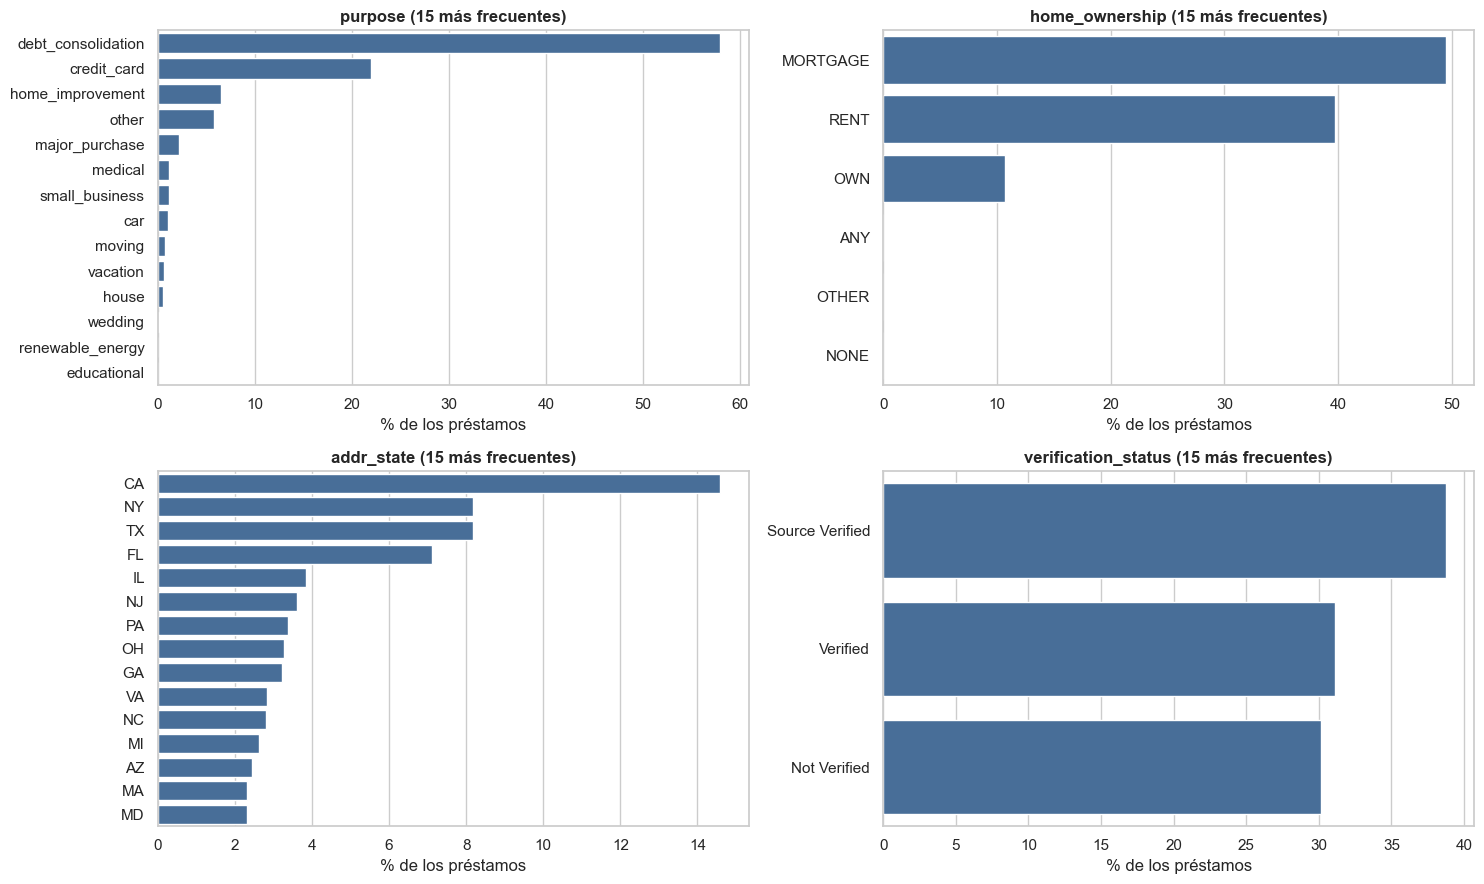

Categorías con < 1 % / total: {'purpose': '6/14', 'home_ownership': '3/6', 'addr_state': '23/51', 'verification_status': '0/3', 'term_months': '0/2'}


In [21]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
for a, c in zip(ax.ravel(), lc.CATEGORICAL):
    t = freq_cat[c]["frecuencia relativa %"].head(15)
    sns.barplot(x=t.values, y=t.index, ax=a, color="#3b6ea5")
    a.set(title=f"{c} (15 más frecuentes)", xlabel="% de los préstamos", ylabel="")
plt.tight_layout()
plt.show()
resumen_rara = {c: (int(t[COL_RARA].sum()), len(t)) for c, t in freq_cat.items()}
print("Categorías con < 1 % / total:", {k: f"{a}/{b}" for k, (a, b) in resumen_rara.items()})

De las tablas y el resumen anteriores se desprende lo siguiente:

* `purpose` está dominada por una categoría (`debt_consolidation`) y varias categorías tienen
  menos del 1 % de los préstamos.
* `home_ownership`: hay categorías residuales (`ANY`, `NONE`, `OTHER`) que pueden unificarse.
* `addr_state`: 51 categorías, de las cuales muchas tienen menos del 1 %.
* **Decisión:** las categorías con < 1 % del entrenamiento se agruparán en una sola ("infrecuente")
  en el `OneHotEncoder`. Esto reduce dimensionalidad y evita columnas casi vacías.
* No hay categorías redundantes con distinto nombre; `Desconocido` agrupa los pocos nulos.

### 1.6.3 Variable objetivo `default` y desbalance

,préstamos,%
clase,,
0 = Fully Paid,861401,80.037
1 = Charged Off,214847,19.963


Razón de desbalance: 4.0 pagados por cada incumplido


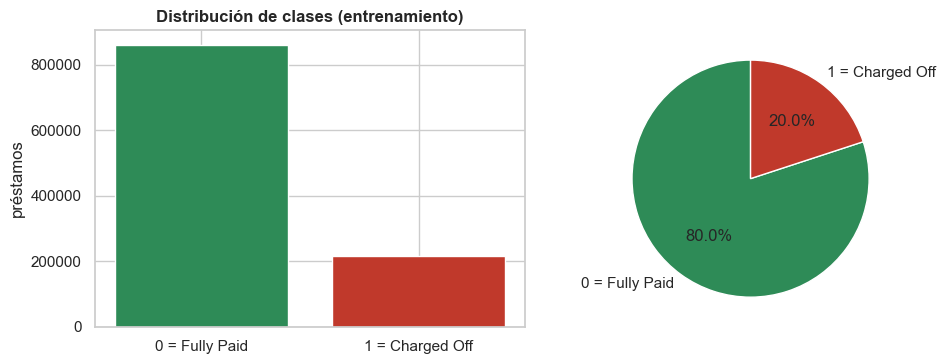

In [22]:
vc = m["default"].value_counts().sort_index()
dist = pd.DataFrame({"clase": ["0 = Fully Paid", "1 = Charged Off"], "préstamos": vc.values,
                     "%": 100 * vc.values / len(m)})
display(dist.set_index("clase"))
RAZON_DESBALANCE = vc[0] / vc[1]
print(f"Razón de desbalance: {RAZON_DESBALANCE:.1f} pagados por cada incumplido")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].bar(dist["clase"], dist["préstamos"], color=["#2e8b57", "#c0392b"])
ax[0].set(title="Distribución de clases (entrenamiento)", ylabel="préstamos")
ax[1].pie(dist["préstamos"], labels=dist["clase"], autopct="%1.1f%%", colors=["#2e8b57", "#c0392b"], startangle=90)
plt.tight_layout()
plt.show()

**Impacto del desbalance (≈ 80 / 20).**

1. **La exactitud es engañosa:** un modelo que predijera "todos pagan" tendría ≈ 80 % de exactitud y sería
   inútil. Se reportan AUC, AUC-PR, sensibilidad (*recall*) y F1.
2. **Estratificar:** la partición entrenamiento/prueba y la validación cruzada mantienen la
   proporción 80/20 en cada pliegue.
3. **Umbral:** con clases desbalanceadas las probabilidades de la clase minoritaria rara vez pasan
   0.5; el umbral de decisión se elegirá con datos de entrenamiento (fuera de pliegue), no con el conjunto de prueba.
4. **Balanceo:** no se aplica remuestreo (SMOTE, etc.) ni pesos por clase (`class_weight`): la clase
   minoritaria tiene más de 200 000 ejemplos en el entrenamiento, suficientes para estimarla, y el desbalance (≈ 4:1) es
   moderado; se maneja con métricas que no dependen de la prevalencia y con el umbral. Los pesos por
   clase o SMOTE son alternativas válidas que **no se probaron aquí**: cambiarían las probabilidades
   del modelo (habría que recalibrarlas) y el umbral óptimo.
5. **Qué error importa más:** en crédito, prestar a quien no pagará (falso negativo) puede perder
   buena parte del capital (menos las recuperaciones); rechazar a quien sí pagaría (falso positivo)
   pierde solo los intereses. Por eso se
   presta atención a la sensibilidad y al F1, y no a la exactitud.

## 1.7 Análisis bidimensional

### 1.7.1 Variables numéricas vs `default`

Con más de un millón de filas, casi toda diferencia resulta "estadísticamente significativa"
(los valores p quedan por debajo de 0.001, muchas veces por debajo de la precisión de impresión):
el tamaño de muestra vuelve significativas diferencias minúsculas. Por eso, además del valor p, se reporta el
**tamaño del efecto**: *d* de Cohen (diferencia de medias en desviaciones estándar) y la
correlación punto-biserial. Criterio de referencia (Cohen, 1988): |d| < 0.2 efecto pequeño · 0.2–0.5 moderado · > 0.5 grande.

In [23]:
# term_months solo toma dos valores (36 o 60 meses): se trata como categórica más abajo, no aquí, donde
# un d de Cohen o una prueba t no tendrían sentido (una variable de dos valores no es continua).
NUM_CONTINUAS = [c for c in lc.NUMERIC if c != "term_months"]
filas = []
for c in NUM_CONTINUAS:
    x1 = m.loc[m["default"] == 1, c].dropna()
    x0 = m.loc[m["default"] == 0, c].dropna()
    n1, n0 = len(x1), len(x0)
    welch = stats.ttest_ind(x1, x0, equal_var=False)
    mw = stats.mannwhitneyu(x1, x0, alternative="two-sided", method="asymptotic")
    sp = np.sqrt(((n1 - 1) * x1.var() + (n0 - 1) * x0.var()) / (n1 + n0 - 2))
    ok = m[c].notna()
    filas.append({"variable": c, "media default=1": x1.mean(), "media default=0": x0.mean(),
                  "dif. de medias": x1.mean() - x0.mean(), "d de Cohen": (x1.mean() - x0.mean()) / sp,
                  "corr. punto-biserial": stats.pointbiserialr(m.loc[ok, "default"], m.loc[ok, c]).statistic,
                  "p Welch": welch.pvalue, "p Mann-Whitney": mw.pvalue})
bi_num = pd.DataFrame(filas).set_index("variable").sort_values("corr. punto-biserial", key=abs, ascending=False)
bi_num.to_csv(RESULTS / "eda_bivariado_numericas.csv")
display(bi_num)

,media default=1,media default=0,dif. de medias,d de Cohen,corr. punto-biserial,p Welch,p Mann-Whitney
variable,,,,,,,
int_rate,15.719,12.624,3.095,0.672,0.259,0.000,0.000
fico_range_high,691.858,702.272,-10.414,-0.330,-0.131,0.000,0.000
dti,20.164,17.818,2.346,0.208,0.083,0.000,0.000
mort_acc,1.370,1.746,-0.376,-0.189,-0.075,0.000,0.000
inq_last_6mths,0.778,0.625,0.153,0.163,0.065,0.000,0.000
loan_amnt,"15,558.321","14,137.267","1,421.054",0.163,0.065,0.000,0.000
revol_util,54.746,51.091,3.655,0.149,0.060,0.000,0.000
installment,465.026,431.406,33.620,0.129,0.051,0.000,0.000
annual_inc,"70,364.974","77,707.745","-7,342.771",-0.106,-0.042,0.000,0.000


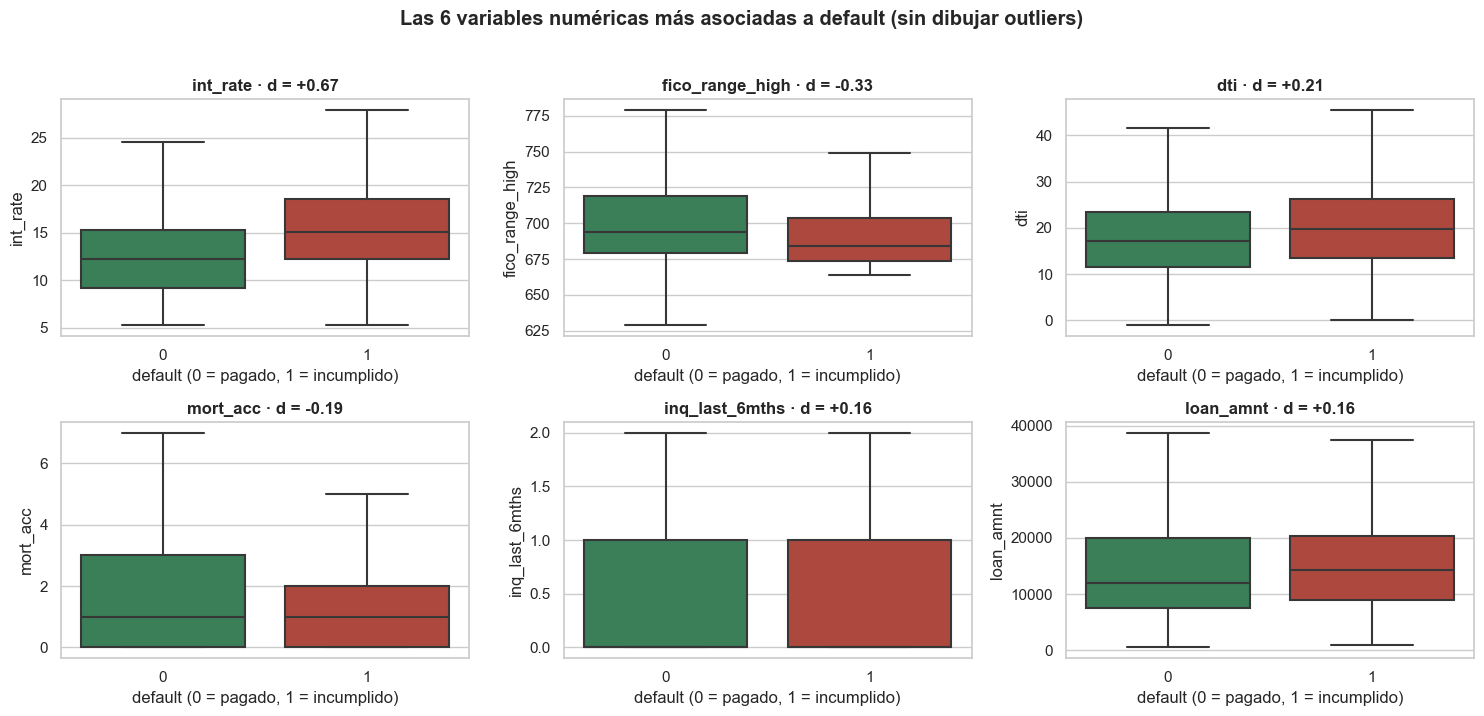

In [24]:
top6 = bi_num.index[:6].tolist()
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, c in zip(ax.ravel(), top6):
    sns.boxplot(data=m, x="default", y=c, ax=a, showfliers=False, palette=["#2e8b57", "#c0392b"])
    a.set(title=f"{c} · d = {bi_num.loc[c, 'd de Cohen']:+.2f}", xlabel="default (0 = pagado, 1 = incumplido)")
plt.suptitle("Las 6 variables numéricas más asociadas a default (sin dibujar outliers)", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

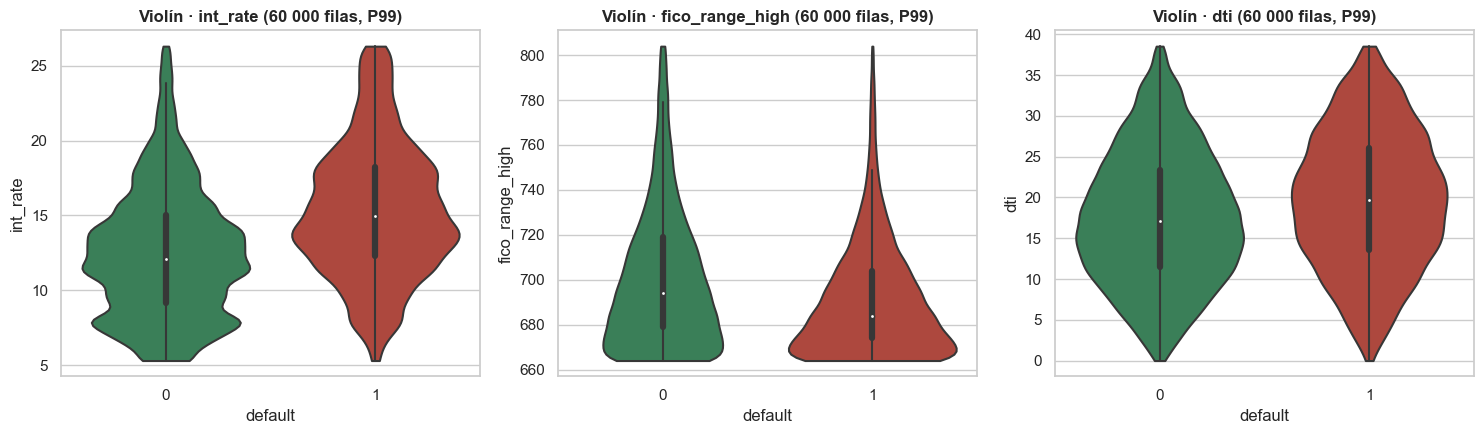

In [25]:
vio = m.sample(60000, random_state=lc.SEED)      # solo para dibujar
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, c in zip(ax, ["int_rate", "fico_range_high", "dti"]):
    d = vio[vio[c] <= vio[c].quantile(0.99)]
    sns.violinplot(data=d, x="default", y=c, ax=a, palette=["#2e8b57", "#c0392b"], cut=0)
    a.set(title=f"Violín · {c} (60 000 filas, P99)")
plt.tight_layout()
plt.show()

In [26]:
tabla_term = pd.crosstab(m["term_months"], m["default"])
tasa_term = (100 * m.groupby("term_months")["default"].mean()).rename("tasa de incumplimiento (%)")
v_term = lc.cramers_v(m["term_months"], m["default"])
display(pd.concat([tabla_term, tasa_term], axis=1))
print(f"V de Cramér (term_months vs default) = {v_term:.2f}")

,0,1,tasa de incumplimiento (%)
term_months,,,
36,686017,130569,15.990
60,175384,84278,32.457


V de Cramér (term_months vs default) = 0.18


La tabla ordena las variables **continuas** por su asociación con el incumplimiento. `int_rate` (la
tasa que Lending Club asigna según su propio análisis de riesgo) es, con diferencia, la de mayor
efecto (|d| ≈ 0.7, efecto grande); `fico_range_high` tiene un efecto moderado; `dti` queda justo en el
límite (d ≈ 0.21) y el resto por debajo de 0.2 (efecto pequeño). `term_months`, al ser binaria (36 o
60 meses), se trata aparte: los préstamos a 60 meses incumplen el doble que los de 36 (32.5 % frente a
16.0 %; V de Cramér = 0.18), una asociación moderada. Aun así, "efecto pequeño" no significa "inútil":
varias variables débiles combinadas pueden aportar. Ninguna variable sola separa bien las clases (los
diagramas de caja y de violín se solapan mucho), por eso se espera un AUC moderado.

### 1.7.2 Variables categóricas vs `default`

Tabla de contingencia con la **tasa de incumplimiento** por categoría, prueba χ² de independencia
y **V de Cramér** (tamaño del efecto: < 0.1 débil · 0.1–0.3 moderado · > 0.3 fuerte).

In [27]:
resumen_cat = []
for c in lc.CATEGORICAL + ["term_months"]:
    tab = pd.crosstab(m[c], m["default"])
    chi2, p, dof, _ = stats.chi2_contingency(tab, correction=False)
    resumen_cat.append({"variable": c, "categorías": tab.shape[0], "χ²": chi2, "gl": dof, "p-valor": p,
                        "V de Cramér": lc.cramers_v(m[c], m["default"])})
resumen_cat = pd.DataFrame(resumen_cat).set_index("variable").sort_values("V de Cramér", ascending=False)
resumen_cat.to_csv(RESULTS / "eda_bivariado_categoricas.csv")
display(resumen_cat)
print("Tasa de default por plazo:", {f"{int(k)} meses": f"{v:.1%}" for k, v in m.groupby("term_months")["default"].mean().items()})

,categorías,χ²,gl,p-valor,V de Cramér
variable,,,,,
term_months,2,"33,436.974",1,0.000,0.176
verification_status,3,"9,203.081",2,0.000,0.092
home_ownership,6,"5,402.552",5,0.000,0.071
purpose,14,"3,322.645",13,0.000,0.055
addr_state,51,"2,731.943",50,0.000,0.050


Tasa de default por plazo: {'36 meses': '16.0%', '60 meses': '32.5%'}


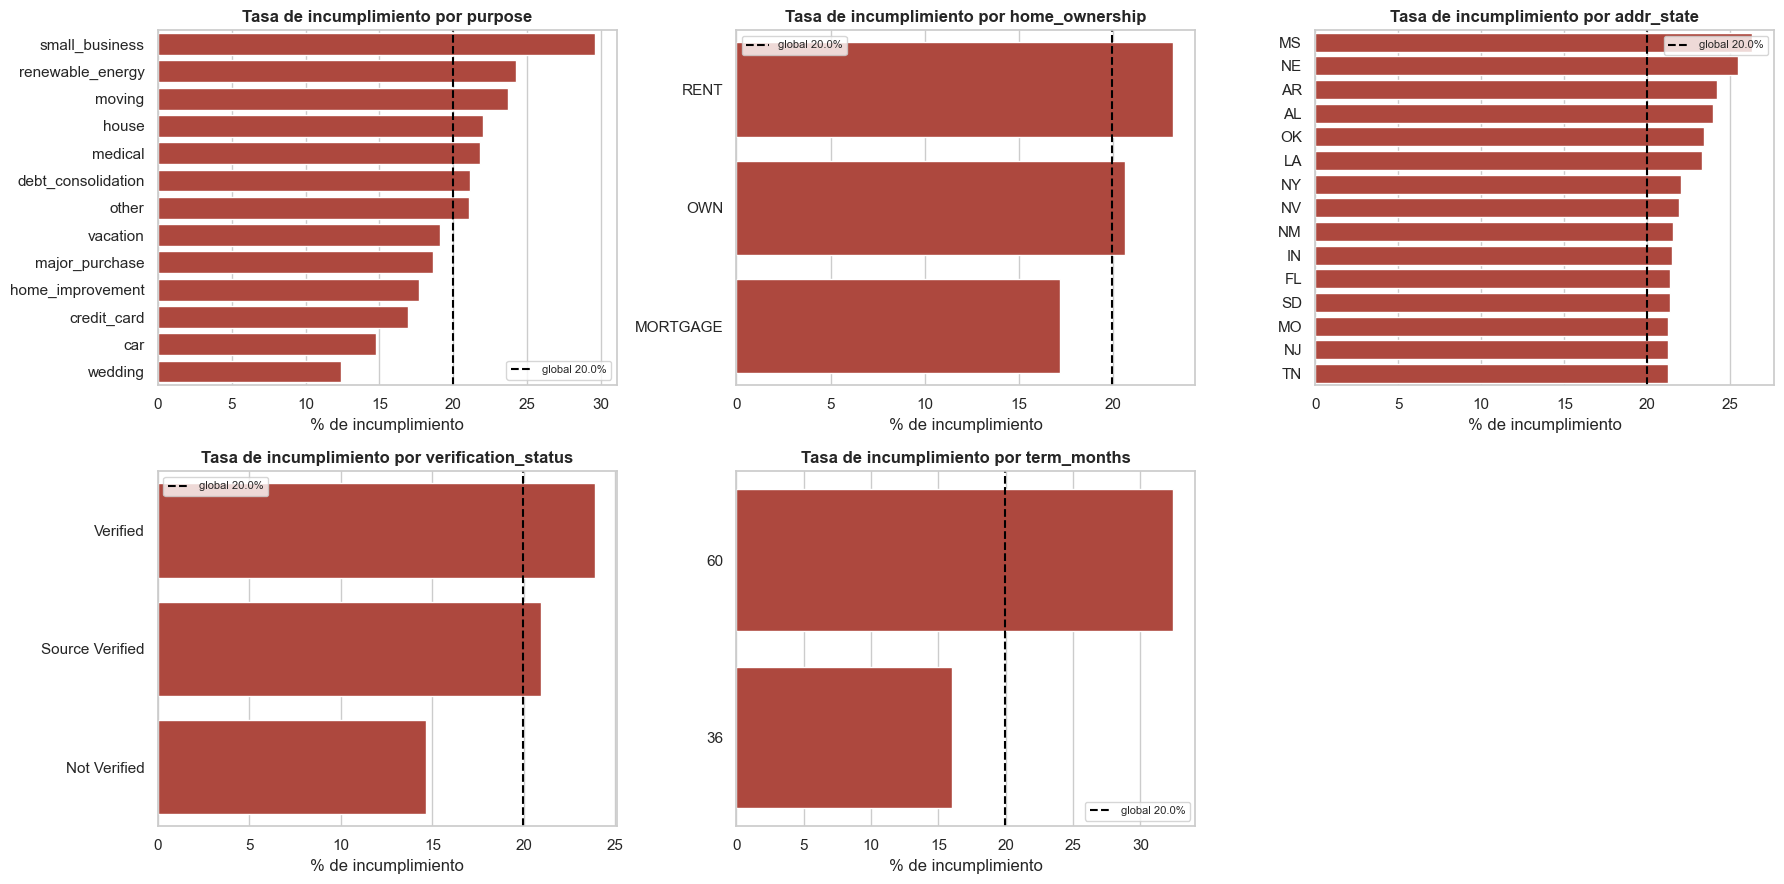

In [28]:
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
tasa_global = m["default"].mean()
for a, c in zip(ax.ravel(), lc.CATEGORICAL + ["term_months"]):
    t = m.groupby(c)["default"].agg(["mean", "size"]).sort_values("mean", ascending=False)
    t = t[t["size"] >= 500].head(15)          # evita categorías diminutas en el gráfico
    sns.barplot(x=t["mean"] * 100, y=t.index.astype(str), ax=a, color="#c0392b")
    a.axvline(tasa_global * 100, color="black", ls="--", label=f"global {tasa_global:.1%}")
    a.set(title=f"Tasa de incumplimiento por {c}", xlabel="% de incumplimiento", ylabel="")
    a.legend(fontsize=8)
for a in ax.ravel()[len(lc.CATEGORICAL) + 1:]:
    a.remove()                                # la cuadrícula tiene un panel más que variables
plt.tight_layout()
plt.show()

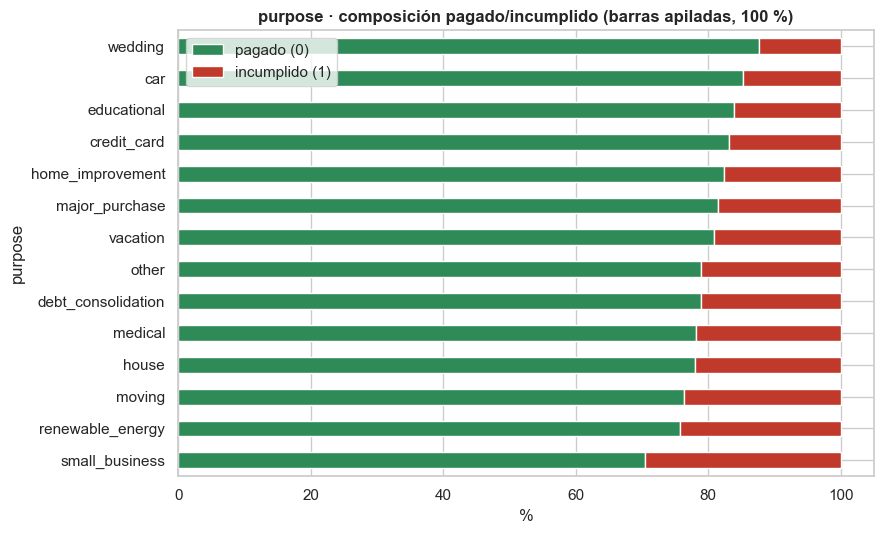

,tasa de default,préstamos
purpose,,
small_business,29.6%,"12,397"
renewable_energy,24.3%,734
moving,23.7%,"7,617"
house,22.0%,"5,803"
credit_card,16.9%,"236,042"
educational,16.1%,267
car,14.8%,"11,684"
wedding,12.4%,"1,859"


In [29]:
cat_top = m.groupby("purpose")["default"].agg(tasa="mean", n="size").sort_values("tasa", ascending=False)
apil = pd.crosstab(m["purpose"], m["default"], normalize="index").loc[cat_top.index] * 100
apil.columns = ["pagado (0)", "incumplido (1)"]
ax = apil.plot.barh(stacked=True, figsize=(9, 5.5), color=["#2e8b57", "#c0392b"])
ax.set(title="purpose · composición pagado/incumplido (barras apiladas, 100 %)", xlabel="%")
plt.tight_layout()
plt.show()
display(pd.concat([cat_top.head(4), cat_top.tail(4)]).rename(columns={"tasa": "tasa de default", "n": "préstamos"})
        .style.format({"tasa de default": "{:.1%}", "préstamos": "{:,.0f}"}))

La tabla de V de Cramér ordena las categóricas por la fuerza de su asociación con el
incumplimiento; el plazo (`term_months`) es la más asociada. Con más de un millón de filas, la
prueba χ² da p < 0.001 en todos los casos, así que **el valor p no distingue entre ellas** y por
eso se usa el V de Cramér como criterio. El gráfico y la
tabla de `purpose` (4 categorías con más y 4 con menos incumplimiento) muestran que las diferencias
entre propósitos existen pero son moderadas. `addr_state` casi no separa clases entre estados
grandes.

## 1.8 Multicolinealidad

### 1.8.1 Entre variables numéricas (Pearson)

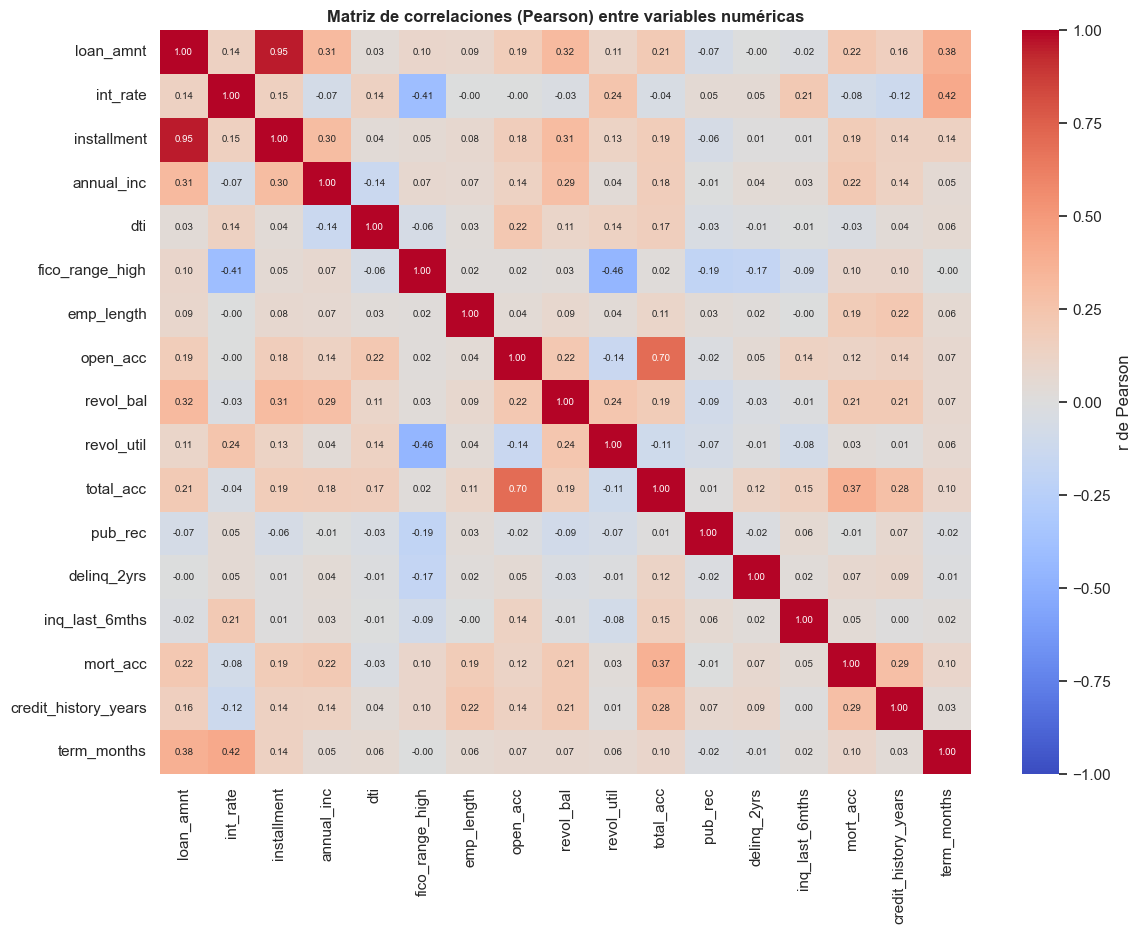

Pares con |r| > 0.7: 2


,,r
variable A,variable B,
loan_amnt,installment,0.953
open_acc,total_acc,0.702


In [30]:
corr = m[lc.NUMERIC].corr(method="pearson")
fig, ax = plt.subplots(figsize=(12, 9.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 7}, cbar_kws={"label": "r de Pearson"})
ax.set_title("Matriz de correlaciones (Pearson) entre variables numéricas")
plt.tight_layout()
plt.show()

iu = np.triu_indices_from(corr, k=1)
pares = pd.DataFrame({"variable A": corr.index[iu[0]], "variable B": corr.columns[iu[1]], "r": corr.values[iu]})
altos = pares[pares["r"].abs() > 0.7].sort_values("r", key=abs, ascending=False)
print(f"Pares con |r| > 0.7: {len(altos)}")
display(altos.set_index(["variable A", "variable B"]))

**Variables candidatas descartadas por redundancia.** Se comprueba también con columnas que
*no* entran al modelo, para justificar por qué se dejaron fuera:

In [31]:
red = pd.DataFrame({
    "fico_range_high vs fico_range_low": [m["fico_range_high"].corr(extra["fico_range_low"])],
    "loan_amnt vs funded_amnt": [m["loan_amnt"].corr(extra["funded_amnt"])],
    "loan_amnt vs installment": [m["loan_amnt"].corr(m["installment"])],
    "int_rate vs grade (código ordinal)": [m["int_rate"].corr(extra["grade"].astype("category").cat.codes.astype(float))],
    "open_acc vs total_acc": [m["open_acc"].corr(m["total_acc"])],
}, index=["r de Pearson"]).T
display(red)

,r de Pearson
fico_range_high vs fico_range_low,1.000
loan_amnt vs funded_amnt,1.000
loan_amnt vs installment,0.953
int_rate vs grade (código ordinal),0.953
open_acc vs total_acc,0.702


* `fico_range_low` es prácticamente idéntica a `fico_range_high` (r ≈ 1): se conserva solo
  `fico_range_high`, porque la otra es redundante.
* `funded_amnt` ≈ `loan_amnt` (r ≈ 1): redundante, no se usa.
* `int_rate` se deriva de la subcategoría de riesgo (`grade`/`sub_grade`) que Lending Club asigna al
  originar el préstamo (r = 0.95 con el código ordinal de `grade`): ambas codifican la misma evaluación
  interna, así que se conserva solo la tasa (`int_rate`) y no `grade`/`sub_grade`.
* `loan_amnt` e `installment` (r > 0.9) e `open_acc`/`total_acc` (r ≈ 0.7) sí se mantienen: aportan
  información distinta (la cuota incorpora además el plazo y la tasa) y, para los modelos de árbol, la
  colinealidad no sesga el resultado, solo reparte la importancia entre las variables (se tiene en
  cuenta al interpretar). Para la regresión logística y la SVM lineal sí puede inflar la varianza de
  los coeficientes; se conservan porque ambos modelos usan regularización L2, que atenúa ese efecto.

### 1.8.2 Entre variables categóricas (V de Cramér)

In [32]:
cv = pd.DataFrame(index=lc.CATEGORICAL, columns=lc.CATEGORICAL, dtype=float)
muestra_cv = m.sample(300000, random_state=lc.SEED)     # V de Cramér entre pares, con 300 000 filas por costo
for a in lc.CATEGORICAL:
    for b in lc.CATEGORICAL:
        cv.loc[a, b] = 1.0 if a == b else lc.cramers_v(muestra_cv[a], muestra_cv[b])
display(cv.round(3))
print("Nota: el V de Cramér entre pares de variables se calcula con 300 000 filas de entrenamiento al azar por "
      "costo computacional; el resto de análisis usa todas las filas de entrenamiento.")

,purpose,home_ownership,addr_state,verification_status
purpose,1.000,0.087,0.021,0.062
home_ownership,0.087,1.000,0.112,0.029
addr_state,0.021,0.112,1.000,0.022
verification_status,0.062,0.029,0.022,1.000


Nota: el V de Cramér entre pares de variables se calcula con 300 000 filas de entrenamiento al azar por costo computacional; el resto de análisis usa todas las filas de entrenamiento.


Las variables categóricas están poco asociadas entre sí (ver la matriz): no hay una redundancia
fuerte que justifique excluir alguna.

## 1.9 Visualizaciones avanzadas

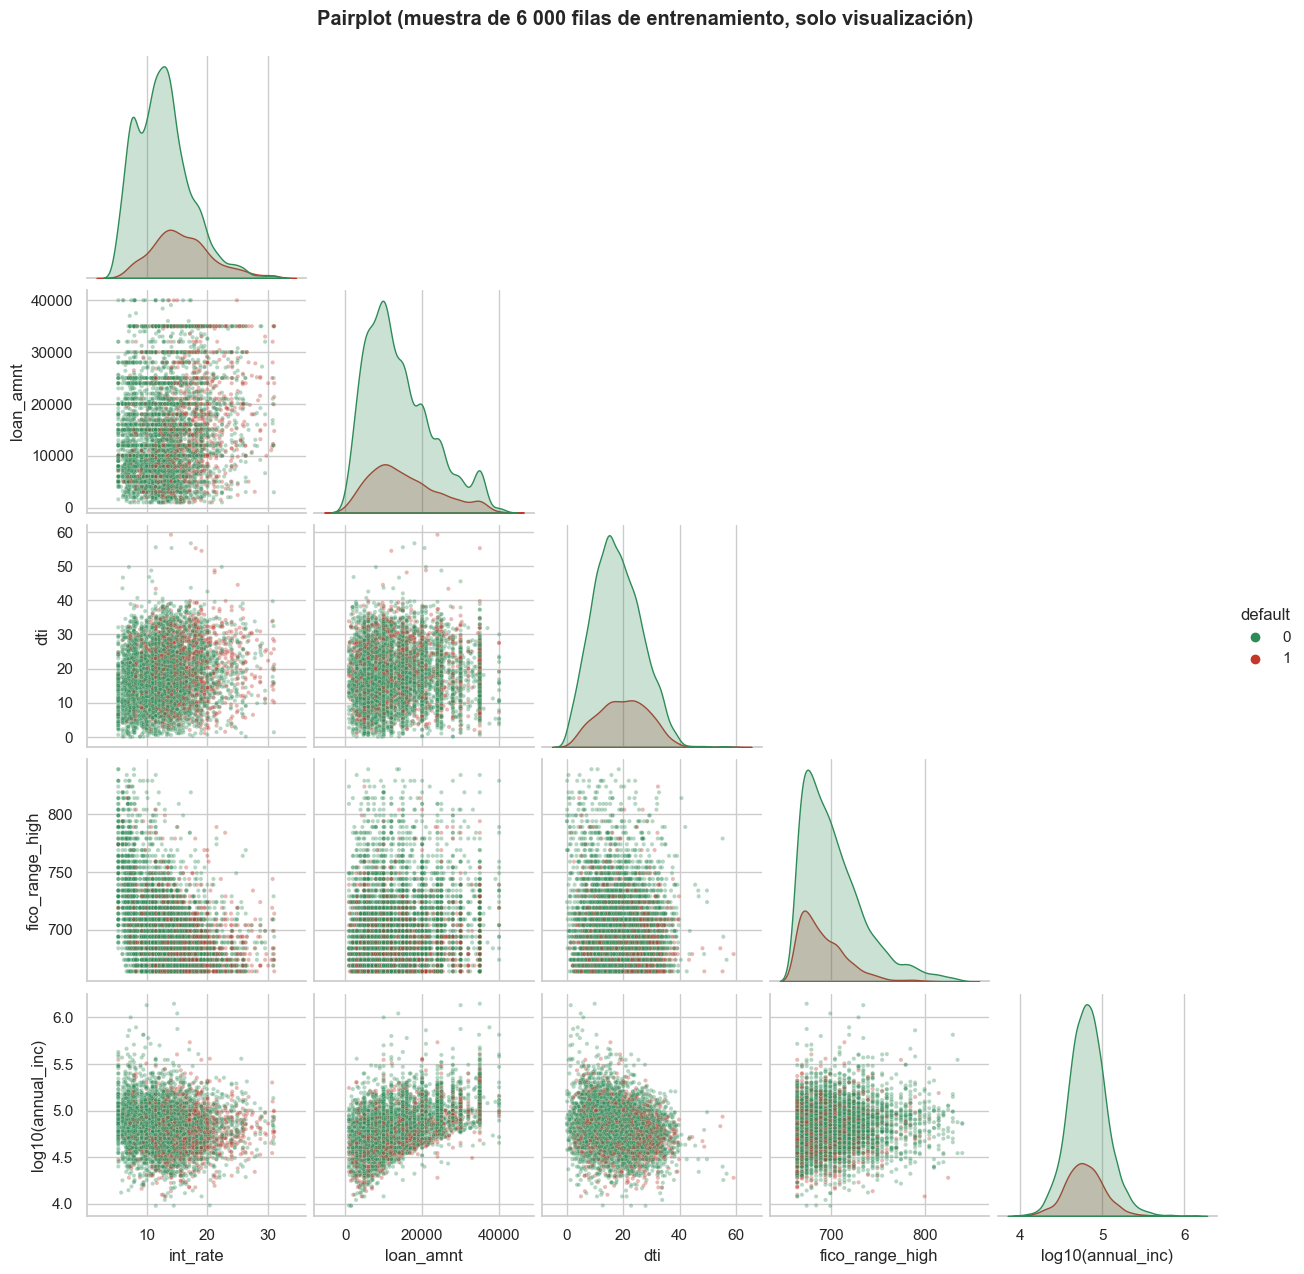

In [33]:
cols_pp = ["int_rate", "loan_amnt", "dti", "fico_range_high", "annual_inc"]
pp = m.sample(6000, random_state=lc.SEED)[cols_pp + ["default"]].copy()
pp["annual_inc"] = np.log10(pp["annual_inc"].clip(lower=1))
pp = pp.rename(columns={"annual_inc": "log10(annual_inc)"})
pp = pp[pp["dti"].between(0, 60)]
g = sns.pairplot(pp, hue="default", corner=True, palette=["#2e8b57", "#c0392b"],
                 plot_kws={"alpha": 0.35, "s": 9}, diag_kind="kde")
g.figure.suptitle("Pairplot (muestra de 6 000 filas de entrenamiento, solo visualización)", y=1.02, fontweight="bold")
plt.show()

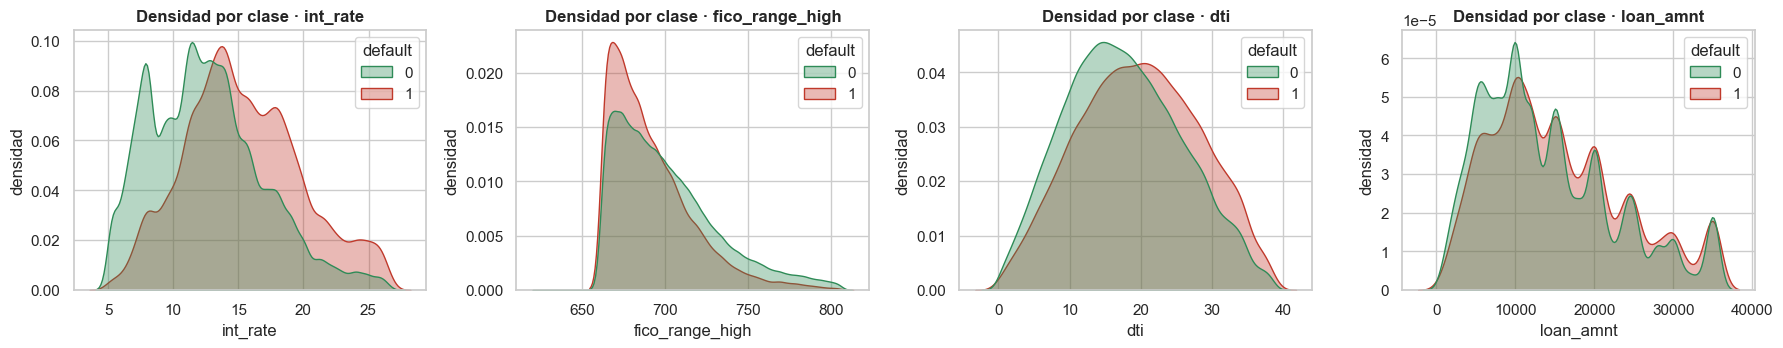

In [34]:
kd = m.sample(150000, random_state=lc.SEED)
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
for a, c in zip(ax, ["int_rate", "fico_range_high", "dti", "loan_amnt"]):
    d = kd[kd[c] <= kd[c].quantile(0.99)]
    sns.kdeplot(data=d, x=c, hue="default", common_norm=False, fill=True, alpha=0.35,
                palette=["#2e8b57", "#c0392b"], ax=a)
    a.set(title=f"Densidad por clase · {c}", ylabel="densidad")
plt.tight_layout()
plt.show()

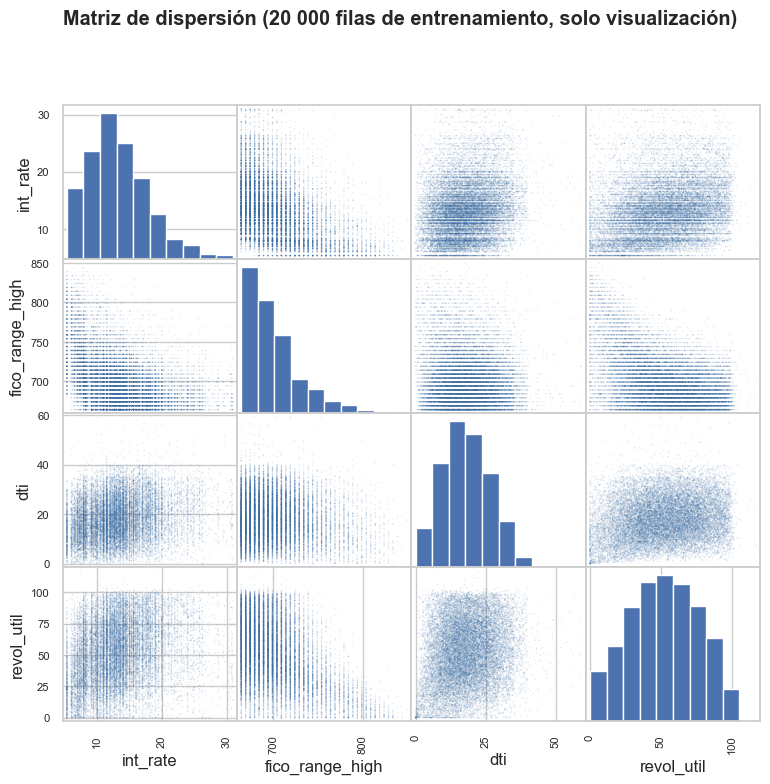

In [35]:
sm = m.sample(20000, random_state=lc.SEED)[["int_rate", "fico_range_high", "dti", "revol_util"]]
sm = sm[(sm["dti"].between(0, 60)) & (sm["revol_util"].between(0, 120))]
pd.plotting.scatter_matrix(sm, figsize=(9, 8), alpha=0.15, diagonal="hist", s=4, color="#3b6ea5")
plt.suptitle("Matriz de dispersión (20 000 filas de entrenamiento, solo visualización)", y=1.0, fontweight="bold")
plt.show()

El *pairplot* y las densidades por clase confirman que las dos clases **se solapan
mucho** en todas las variables: no hay una frontera limpia. Las relaciones entre variables no son
perfectamente lineales (dispersión amplia en la matriz de dispersión), algo que un modelo de
árboles puede capturar sin transformaciones.

## 1.10 Sesgo temporal y censura

Los préstamos se otorgaron entre 2007 y 2018. Los más recientes, sobre todo los de 60 meses,
**aún no han terminado**: si solo se consideran los ya resueltos, los de años recientes están
**sobrerrepresentados en desenlaces rápidos**. Es un problema clásico de **censura**. La primera
tabla usa el archivo completo (solo cuenta filas, sin mirar la variable objetivo de la prueba); la
tasa de incumplimiento se calcula con el entrenamiento.

,otorgados (archivo completo),con desenlace conocido (archivo completo),% resuelto,tasa de default (entrenamiento)
issue_d,,,,
2007,603,251,41.6,17.4%
2008,"2,393","1,562",65.3,15.7%
2009,"5,281","4,716",89.3,12.3%
2010,"12,537","11,536",92.0,13.0%
2011,"21,721","21,721",100.0,15.3%
2012,"53,367","53,367",100.0,16.2%
2013,"134,814","134,804",100.0,15.7%
2014,"235,629","223,102",94.7,18.5%
2015,"421,095","375,545",89.2,20.2%


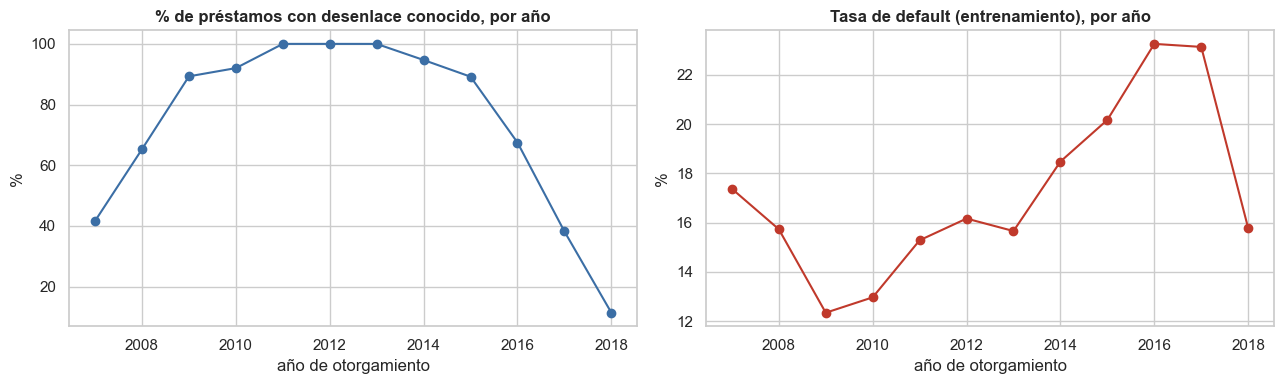

In [36]:
resumen_anio = pd.DataFrame({"otorgados (archivo completo)": anio_todos,
                             "con desenlace conocido (archivo completo)": anio_resueltos})
resumen_anio["% resuelto"] = 100 * resumen_anio["con desenlace conocido (archivo completo)"] / resumen_anio["otorgados (archivo completo)"]
resumen_anio["tasa de default (entrenamiento)"] = m.groupby("issue_year")["default"].mean()
display(resumen_anio.style.format({"otorgados (archivo completo)": "{:,.0f}",
                                   "con desenlace conocido (archivo completo)": "{:,.0f}",
                                   "% resuelto": "{:.1f}", "tasa de default (entrenamiento)": "{:.1%}"}))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
resumen_anio["% resuelto"].plot(marker="o", ax=ax[0], color="#3b6ea5")
ax[0].set(title="% de préstamos con desenlace conocido, por año", ylabel="%", xlabel="año de otorgamiento")
(100 * resumen_anio["tasa de default (entrenamiento)"]).plot(marker="o", ax=ax[1], color="#c0392b")
ax[1].set(title="Tasa de default (entrenamiento), por año", ylabel="%", xlabel="año de otorgamiento")
plt.tight_layout()
plt.show()

Dos consecuencias de este patrón:

* De cierto año en adelante cae el porcentaje de préstamos con desenlace conocido (muchos siguen
  vigentes), y la tasa de incumplimiento de los resueltos deja de ser comparable entre años. El
  modelo aprenderá una mezcla de épocas con **distinta economía y distinto grado de censura**.
* Además de la partición aleatoria estratificada, se incluye una **validación temporal**
  complementaria (entrenar con años anteriores y probar con uno posterior). La validación aleatoria
  tiende a sobrestimar el desempeño cuando los datos tienen estructura temporal, porque el modelo se
  entrena con observaciones posteriores a las que evalúa (Bergmeir y Benítez, 2012).

## 1.11 Resumen ejecutivo del EDA

In [37]:
mas_num = bi_num.index[0], bi_num.index[1]
mas_cat = resumen_cat.index[0], resumen_cat.index[1]
resumen = pd.DataFrame([
    ["Tamaño del archivo", f"{n_filas_archivo:,} filas × {n_cols_archivo} columnas (carga pandas: {T_CARGA_PANDAS:.0f} s)"],
    ["Población y partición", f"{n_train + n_test:,} préstamos con desenlace conocido (Fully Paid / Charged Off): "
                              f"{n_train:,} de entrenamiento y {n_test:,} de prueba (apartada); se excluyen "
                              f"{n_filas_archivo - n_train - n_test:,} vigentes/atrasados/otros"],
    ["Calidad: nulos", f"{N_MAS70} columnas con >70 % de nulos (se descartan); variables del modelo con nulos: "
                       f"{', '.join(nm.index)}"],
    ["Calidad: valores extremos o inválidos", f"{int(sospechosos.iloc[0]):,} fila(s) con dti = −1 (inválido, tratado como faltante); "
                                    f"{int(sospechosos.iloc[1]):,} con dti > 100; {int(sospechosos.iloc[2]):,} con revol_util > 100 % (extremos, se conservan)"],
    ["Desbalance", f"{m['default'].mean():.1%} de incumplimiento (≈ {RAZON_DESBALANCE:.1f}:1)"],
    ["Variables numéricas más asociadas", f"{mas_num[0]} (d = {bi_num.loc[mas_num[0], 'd de Cohen']:+.2f}), "
                                          f"{mas_num[1]} (d = {bi_num.loc[mas_num[1], 'd de Cohen']:+.2f})"],
    ["Variables categóricas más asociadas", f"{mas_cat[0]} (V = {resumen_cat.loc[mas_cat[0], 'V de Cramér']:.2f}), "
                                            f"{mas_cat[1]} (V = {resumen_cat.loc[mas_cat[1], 'V de Cramér']:.2f})"],
    ["Colinealidad", (f"{len(altos)} pares numéricos con |r| > 0.7 (p. ej. {altos.iloc[0, 0]} y {altos.iloc[0, 1]}, "
                      f"r = {altos.iloc[0, 2]:.2f}); " if len(altos) else "ningún par numérico con |r| > 0.7; ")
     + "fico_range_low y funded_amnt redundantes (no usadas)"],
    ["Fuga de datos", f"columnas posteriores al préstamo con AUC individual de hasta {AUD_MAX:.2f}: excluidas del modelo"],
    ["Sesgo temporal", "los préstamos recientes están censurados; se añade validación temporal complementaria"],
], columns=["Hallazgo", "Detalle"]).set_index("Hallazgo")
pd.set_option("display.max_colwidth", 200)
display(resumen)
resumen.to_csv(RESULTS / "eda_resumen.csv")
pd.Series({"t_carga_pandas_s": T_CARGA_PANDAS, "filas": int(n_filas_archivo), "columnas": int(n_cols_archivo),
           "filas_modelo": int(n_train + n_test), "filas_train": int(n_train), "filas_test": int(n_test),
           "tasa_default_train": float(m["default"].mean())}).to_json(RESULTS / "eda_metricas.json")

,Detalle
Hallazgo,
Tamaño del archivo,"2,260,701 filas × 151 columnas (carga pandas: 122 s)"
Población y partición,"1,345,310 préstamos con desenlace conocido (Fully Paid / Charged Off): 1,076,248 de entrenamiento y 269,062 de prueba (apartada); se excluyen 915,391 vigentes/atrasados/otros"
Calidad: nulos,"42 columnas con >70 % de nulos (se descartan); variables del modelo con nulos: emp_length, mort_acc, revol_util, dti, inq_last_6mths"
Calidad: valores extremos o inválidos,"1 fila(s) con dti = −1 (inválido, tratado como faltante); 428 con dti > 100; 3,781 con revol_util > 100 % (extremos, se conservan)"
Desbalance,20.0% de incumplimiento (≈ 4.0:1)
Variables numéricas más asociadas,"int_rate (d = +0.67), fico_range_high (d = -0.33)"
Variables categóricas más asociadas,"term_months (V = 0.18), verification_status (V = 0.09)"
Colinealidad,"2 pares numéricos con |r| > 0.7 (p. ej. loan_amnt y installment, r = 0.95); fico_range_low y funded_amnt redundantes (no usadas)"
Fuga de datos,columnas posteriores al préstamo con AUC individual de hasta 0.94: excluidas del modelo


### Decisiones que guían el preprocesamiento

1. **Población y etiqueta:** solo `Fully Paid` / `Charged Off` (desenlace conocido).
2. **Partición:** 80/20 estratificada, hecha **antes** del EDA; el conjunto de prueba no se tocó.
3. **Variables:** las disponibles al originar el préstamo (17 numéricas + 4 categóricas). Se
   descartan las posteriores al préstamo (fuga), `fico_range_low`, `funded_amnt`, `grade` y
   `sub_grade` (redundantes).
4. **Nulos:** centinela −1 en numéricas (sin parámetros aprendidos ⇒ sin fuga); `Desconocido` en categóricas.
5. **Categóricas:** *One-Hot* agrupando en "infrecuente" las de < 1 % del entrenamiento.
6. **Valores atípicos:** se conservan (en su mayoría son valores extremos posibles y los árboles son
   robustos); los pocos valores imposibles (`dti` < 0) quedan cubiertos por el centinela.
7. **Escalado:** no lo necesitan los modelos de árbol; regresión logística y SVM lineal sí se
   escalan (`StandardScaler`, ajustado solo con el entrenamiento).
8. **Desbalance:** estratificar, métricas robustas (AUC, AUC-PR, sensibilidad, F1) y umbral elegido sin
   el conjunto de prueba. Sin remuestreo.
9. **Validación:** partición aleatoria estratificada 80/20 más validación temporal complementaria.